# ANÁLISIS EXLPORATORIO DE DATOS

A continuacion se presenta el análisis exploratorio de los datos obtenidos para el desarrollo de un Sistema Clasificador de Resultados de Análisis de Aceite Usado en Motores de Maquinaria Pesada.

Los datos aportados corresponden a los resultados de los análisis de aceite usado de motores de maquinaria pesada en los ultimos 2 años de la organización. A modo de introducción general a este conjunto de datos se puede decir que contienen la información de identificación del equipo del cual la muestra fue tomada, la fecha de toma de la muestra de aceite, los resultados obtenidos por diferentes técnicas de laboratorio de lubricantes como son: resultados de espectrometría, infrarojos y pruebas especificas como la viscosidad a 100°C y el porcentaje de combustible diluido en el aceite; adicionalmente se incluye la calificación realizada por los analisisas de confiabilidad sobre dichos resultados indicando la severidad (Normal, Advertencia o Critico) y el modo de falla (Alta tasa de desgaste metalico, entrada de tierra, entrada de combustible, entre otros).

Esta información fue suministrada en un solo archivo de excel y proviene de la base de datos de análisis del cliente.

A continucación se realiza una lectura preliminar de los datos y se muestran los primeros 5 registros para inspeccionar el contenido y estructura de los datos.

In [11]:
# Abrir csv usando la ruta definida
import pandas as pd
data = pd.read_csv(r"../Data/Data_Anonimizada.csv")
data.head()

,Component ID,Asset ID,Flota,Location,Component Profile,Lubricant,Connection Code,Observation Type,Observation Date,Observation Code,...,Plomo (ppm),Color del Refrigerante,Glycerin (%),Nitrito (ppm),PUNTO DE EBULLICION (°C),Sólidos Totales Disueltos (ppm),Turbidez (NTU),pH,Titanio (ppm),Vanadio (ppm)
0,Component_ID_54,Asset_ID_42,Flota_3,Location_1,Component_Profile_4,Lubricant_1,Connection_Code_63,Fluid Analysis,2025-01-26,Observation_Code_4112,...,0.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Component_ID_42,Asset_ID_30,Flota_2,Location_1,Component_Profile_1,Lubricant_1,Connection_Code_46,Fluid Analysis,2025-01-26,Observation_Code_3219,...,0.09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Component_ID_28,Asset_ID_16,Flota_2,Location_1,Component_Profile_1,Lubricant_1,Connection_Code_32,Fluid Analysis,2025-01-25,Observation_Code_2161,...,0.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Component_ID_19,Asset_ID_10,Flota_1,Location_1,Component_Profile_2,Lubricant_1,Connection_Code_24,Fluid Analysis,2025-01-25,Observation_Code_1738,...,0.91,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Component_ID_20,Asset_ID_10,Flota_1,Location_1,Component_Profile_2,Lubricant_1,Connection_Code_23,Fluid Analysis,2025-01-25,Observation_Code_1732,...,1.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Parte I: Calidad de datos

De acuerdo a lo informado por el cliente las primeras columnas del conjunto de datos fueron anonimizadas para salvaguardar la identidad de la organización y sus activos. Adicionalmente se informa que la base de datos al contener resultados para diversos tipos de componentes contiene columnas que no se usan en los analisis de muestras de aceite de motor, tal es el caso de columnas de resultados relacionados con pruebas de refrigerante y las relacionadas con pruebas de limpieza ISO 4406 usadas para aceites hidraulicos.

### **Descripción de las columnas**
A continuacion se describen todas las columnas del conjunto de datos:
* Component ID: Identificación del componente
* Asset ID: Identificacion del activo (ID de la maquinaria)
* Flota: Grupo de activos al que pertenece la maquinaria
* Location: Grupo de activos en la base de datos de analisis de resultados de aceite usado
* Component Profile: Identificación del perfil de limites que usa la base datos para analisis basado en reglas
* Lubricant: Descripción del tipo de lubricante
* Connection Code: Llave primaria del registro en la base de datos de analisis
* Observation Type: Identificación del tipo de registro, para este caso todos son registros de analisis de fluidos
* Observation Date: Fecha de toma de la muestra de aceite
* Observation Code: ID del registro
* Meter Reading: Lectura del medidor de servicio del componente al momento de la toma de muestra
* All Time Meter Reading: Lectura del medidor de servicio de la maquinaria al momento de la toma de muestra
* Component Age: Horas de servicio del componente
* Observation Interval: Horas de servicio desde la ultima muestra de aceite para el mismo comoponente y maquinaria
* days: Dias desde la ultima muestra de aceite para el mismo comoponente y maquinaria
* Observation Rating: Clasificacion preliminar de severidad de la condición
* Rule Based Rating: Clasificación automatica realizada por el software de analisis
* Lube Age: Horas de servicio del lubricante
* Live: Vida del activo
* Lube Drained: Indica si el lubricante fue cambiado en la ultima intervención del equipo
* Added: Camtidad de aceite completado al componente
* Assigned Condition Rating: Severidad asignada por el analista
* Condition Review Notes: Notas de la revisión realizada por el analista
* Further Recommendations: Recomnendaciones adicionales dadas por el analista
* Fault Effect: Selección del modo de falla
* Reviewed: Fecha de revisión
* Reviewer: Persona que realizó la revisión
* Action Summary: Lista de acciones para el analista
* Boro (ppm): Contenido de boro en partes por millón (ppm)
* Calcio (ppm): Contenido de calcio en partes por millón (ppm)
* Cinc (ppm): Contenido de zinc en partes por millón (ppm)
* Fosforado (ppm): Contenido de fosforo en partes por millón (ppm)
* Magnesio (ppm): Contenido de magnesio en partes por millón (ppm)
* Molibdeno (ppm): Contenido de molibdeno en partes por millón (ppm)
* SILICATOS (ppm): Contenido de silicatos en partes por millón (ppm)
* Agua (%): Contenido de agua en porcentaje (%)
* Dilución por combustible (%): Contenido de combustible en porcentaje (%)
* Hollín JOAP (Abs/cm): Contenido de hollín en la muestra de aceite medido en absorbancia por centimetro (abs/cm)
* Nitración JOAP (Abs/cm): Contenido de nitración en la muestra de aceite medido en absorbancia por centimetro (abs/cm)
* Oxidación JOAP (Abs/cm): Contenido de oxidación en la muestra de aceite medido en absorbancia por centimetro (abs/cm)
* Silicio (ppm): Contenido de silicio en partes por millón (ppm)
* Sodio (ppm): Contenido de sodio en partes por millón (ppm)
* Sulfatación JOAP (Abs/cm): Contenido de sulfatación en la muestra de aceite medido en absorbancia por centimetro (abs/cm)
* Viscosidad @ 100°C (cSt): Viscosidad del aceite a 100°C
* ISO 4406:1999 > 04µ: Contenido de particulas mayores a 4 micras por cada mililitro de lubricante
* ISO 4406:1999 > 06µ: Contenido de particulas mayores a 6 micras por cada mililitro de lubricante
* ISO 4406:1999 > 14µ: Contenido de particulas mayores a 14 micras por cada mililitro de lubricante
* Aluminio (ppm): Contenido de aluminio en partes por millón (ppm)
* Bario (ppm): Contenido de bario en partes por millón (ppm)
* Cadmio (ppm): Contenido de cadmio en partes por millón (ppm)
* Cobre (ppm): Contenido de cobre en partes por millón (ppm)
* Cromo (ppm): Contenido de cromo en partes por millón (ppm)
* Estaño (ppm): Contenido de estaño en partes por millón (ppm)
* Hierro (ppm): Contenido de hierro en partes por millón (ppm)
* Niquel (ppm): Contenido de niquel en partes por millón (ppm)
* Partículas Ferrosas (ppm): Contenido de particulas ferrosas en partes por millón (ppm)
* Plomo (ppm): Contenido de plomo en partes por millón (ppm)
* Color del Refrigerante: Indicador del color del refrigerante (Para muestras de refrigerante)
* Glycerin (%): Porcentaje de glicerina en el refrigerante (Para muestras de refrigerante)
* Nitrito (ppm): Contenido de nitritos en partes por millón (ppm) (Para muestras de refrigerante)
* PUNTO DE EBULLICION (°C): Punto de ebullición del refrigerante (Para muestras de refrigerante)
* Sólidos Totales Disueltos (ppm): Contenido de solidos en suspensión en partes por millón (ppm) (Para muestras de refrigerante)
* Turbidez (NTU): Indicador de la turbidez del refrigerante (Para muestras de refrigerante)
* pH: Potencial de hidrogeno pH de la muestra de refrigerante (Para muestras de refrigerante)
* Titanio (ppm): Contenido de titanio en partes por millón (ppm)
* Vanadio (ppm): Contenido de vanadio en partes por millón (ppm)

### **¿Que significa o como puede entenderse cada fila del dataframe?**
Cada fila representa un resultado de analisis de aceite conteniendo la informacion de identificacion de la muestra y de los resultadois puntuales de diferentes pruebas de laboratorio alos que el lubricante usado es sometido para revelar sus propiedades y contenido de elementos de interes para estimar el estado de "salud" de la maquinaria en terminos de modos de falla potenciales y el grado de severidad.

### **¿Qué tamaño tiene el conjunto de datos?**

In [13]:
data.shape

(4297, 66)

En la muestra de datos compartida se teiene un total de 4297 registros y 66 columnas. Todos los registros corresponden a muestras de aceite de motores de maquinaria pesada.

### **¿Qué tipo de datos tienen las columnas?**

In [15]:
data.dtypes.value_counts()

float64    45
object     20
int64       1
Name: count, dtype: int64

Se tiene un total de 46 columnas numericas (45 de tipo flotante y 1 de tipo entero), las 20 restantes son columnas categoricas de tipo object. Esto permite conocer que el dataframe es mayoritariamente numérico.

### **¿Hay filas duplicadas?**

In [16]:
# Conteno de filas duplicadas
data.duplicated().sum()

np.int64(0)

No se encuentran duplicados a nivel de filas. Por lo que el conjunto de datos contiene registros unicos. Este es un punto importante en la revisión de calidad de los datos.

### **Análisis de Completitud de los datos**

In [19]:
# Generar una tabla con porcentaje de faltantes por columnas y otra columna de cardinalidad por columna
faltantes = pd.DataFrame({
    'Faltantes': data.isnull().mean() * 100,
}) 
faltantes.sort_values(by='Faltantes', ascending=False)


,Faltantes
Titanio (ppm),100.0
Niquel (ppm),100.0
Cadmio (ppm),100.0
ISO 4406:1999 > 04µ,100.0
Vanadio (ppm),100.0
...,...
Meter Reading,0.0
Component Age,0.0
All Time Meter Reading,0.0
Observation Rating,0.0


In [21]:
cardinalidad = pd.DataFrame({
    'cardinalidad': data.nunique()
})
cardinalidad.sort_values(by='cardinalidad', ascending=True)

,cardinalidad
Bario (ppm),0
ISO 4406:1999 > 06µ,0
Niquel (ppm),0
Cadmio (ppm),0
ISO 4406:1999 > 04µ,0
...,...
Meter Reading,3411
All Time Meter Reading,3678
Component Age,3949
Live,3949


Los anteriores resultados indican que se tiene un numero importante de columnas practicamente vacias, con un % de faltantes igual o cercano a 100%. Entre ellas se tienen:
* `Titanio (ppm)`
* `Niquel (ppm)`
* `Cadmio (ppm)`
* `ISO 4406:1999 > 04µ`
* `Bario (ppm)`
* `ISO 4406:1999 > 14µ`
* `SILICATOS (ppm)`
* `PUNTO DE EBULLICION (°C)`
* `Glycerin (%)`
* `Color del Refrigerante`
* `pH`
* `Turbidez (NTU)`
* `Nitrito (ppm)`
* `Sólidos Totales Disueltos (ppm)`
* `Lube Age`
* `Action Summary`

Por otra parte tambien se tienen columnas con una cardinalidad muy baja, algunas incluso con cardinalidad igual a 1 lo que las hace inutiles para la construccion de modelos predictibvos, tal es el caso de:
* `Added`
* `Color del Refrigerante`
* `Observation Type`
* `Lube Drained`
* `Location`
* `Lubricant`

Estas columnas al estar vacias o poseer una única categoria o valor deberan ser eliminadas del conjunto de datos.

<Axes: >

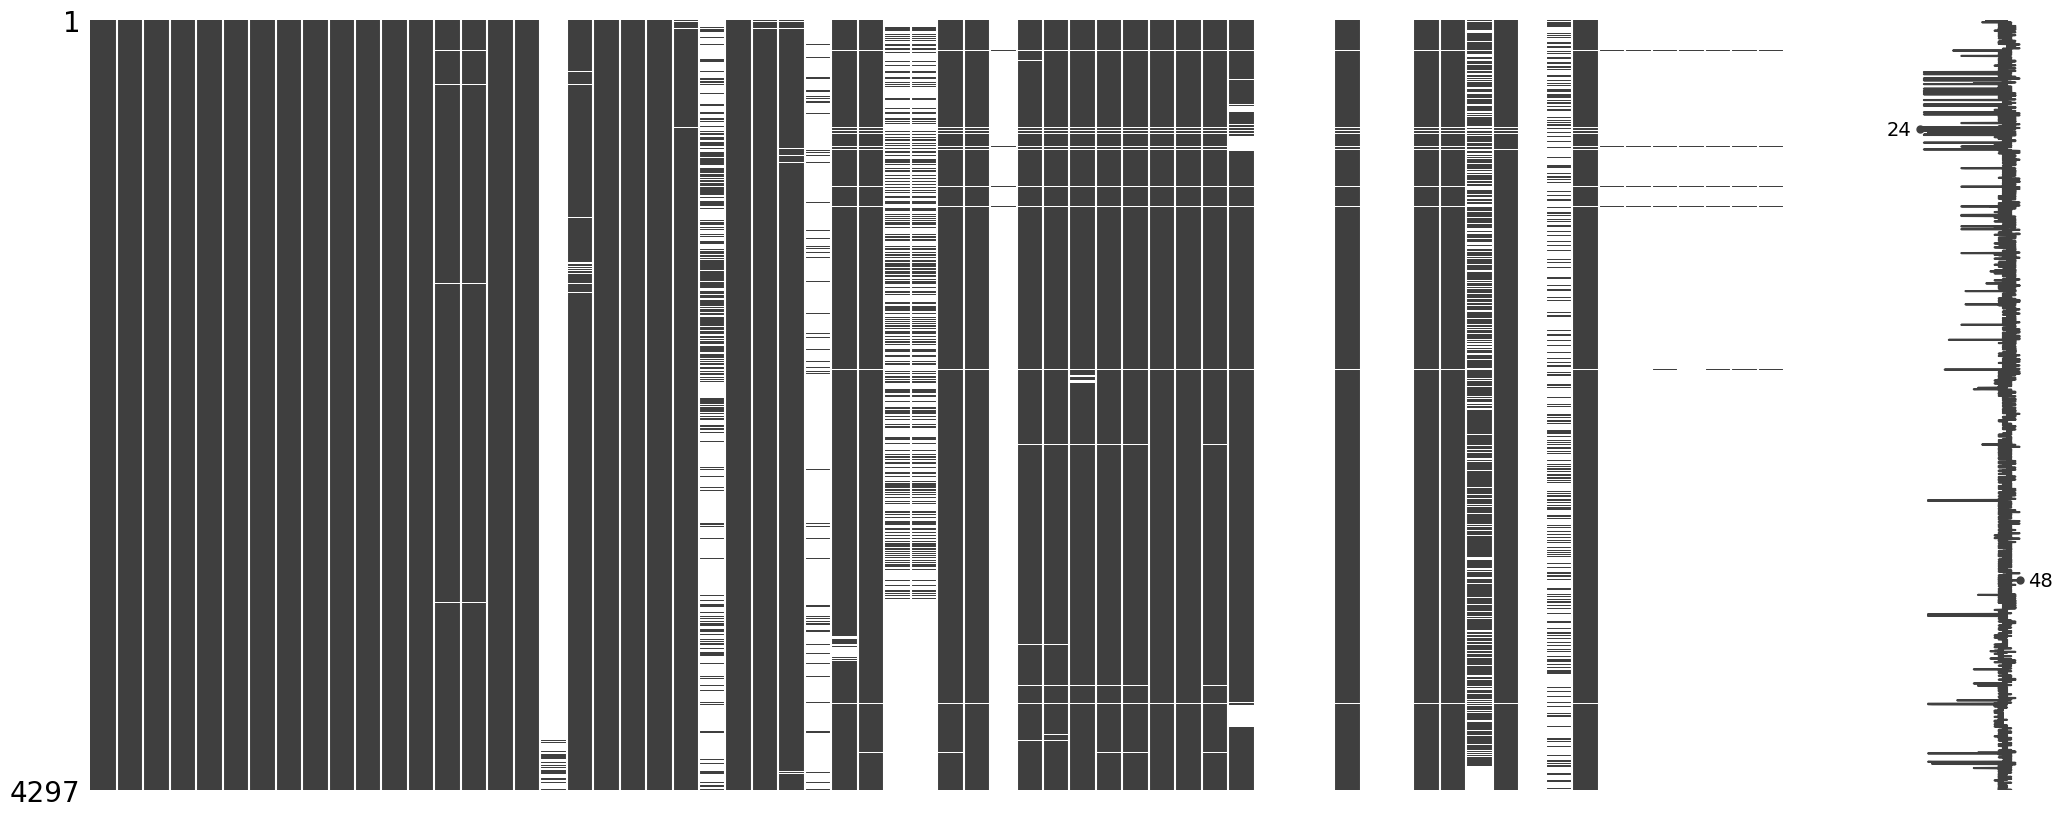

In [22]:
import missingno as msno
msno.matrix(data)

<Figure size 3200x2000 with 0 Axes>

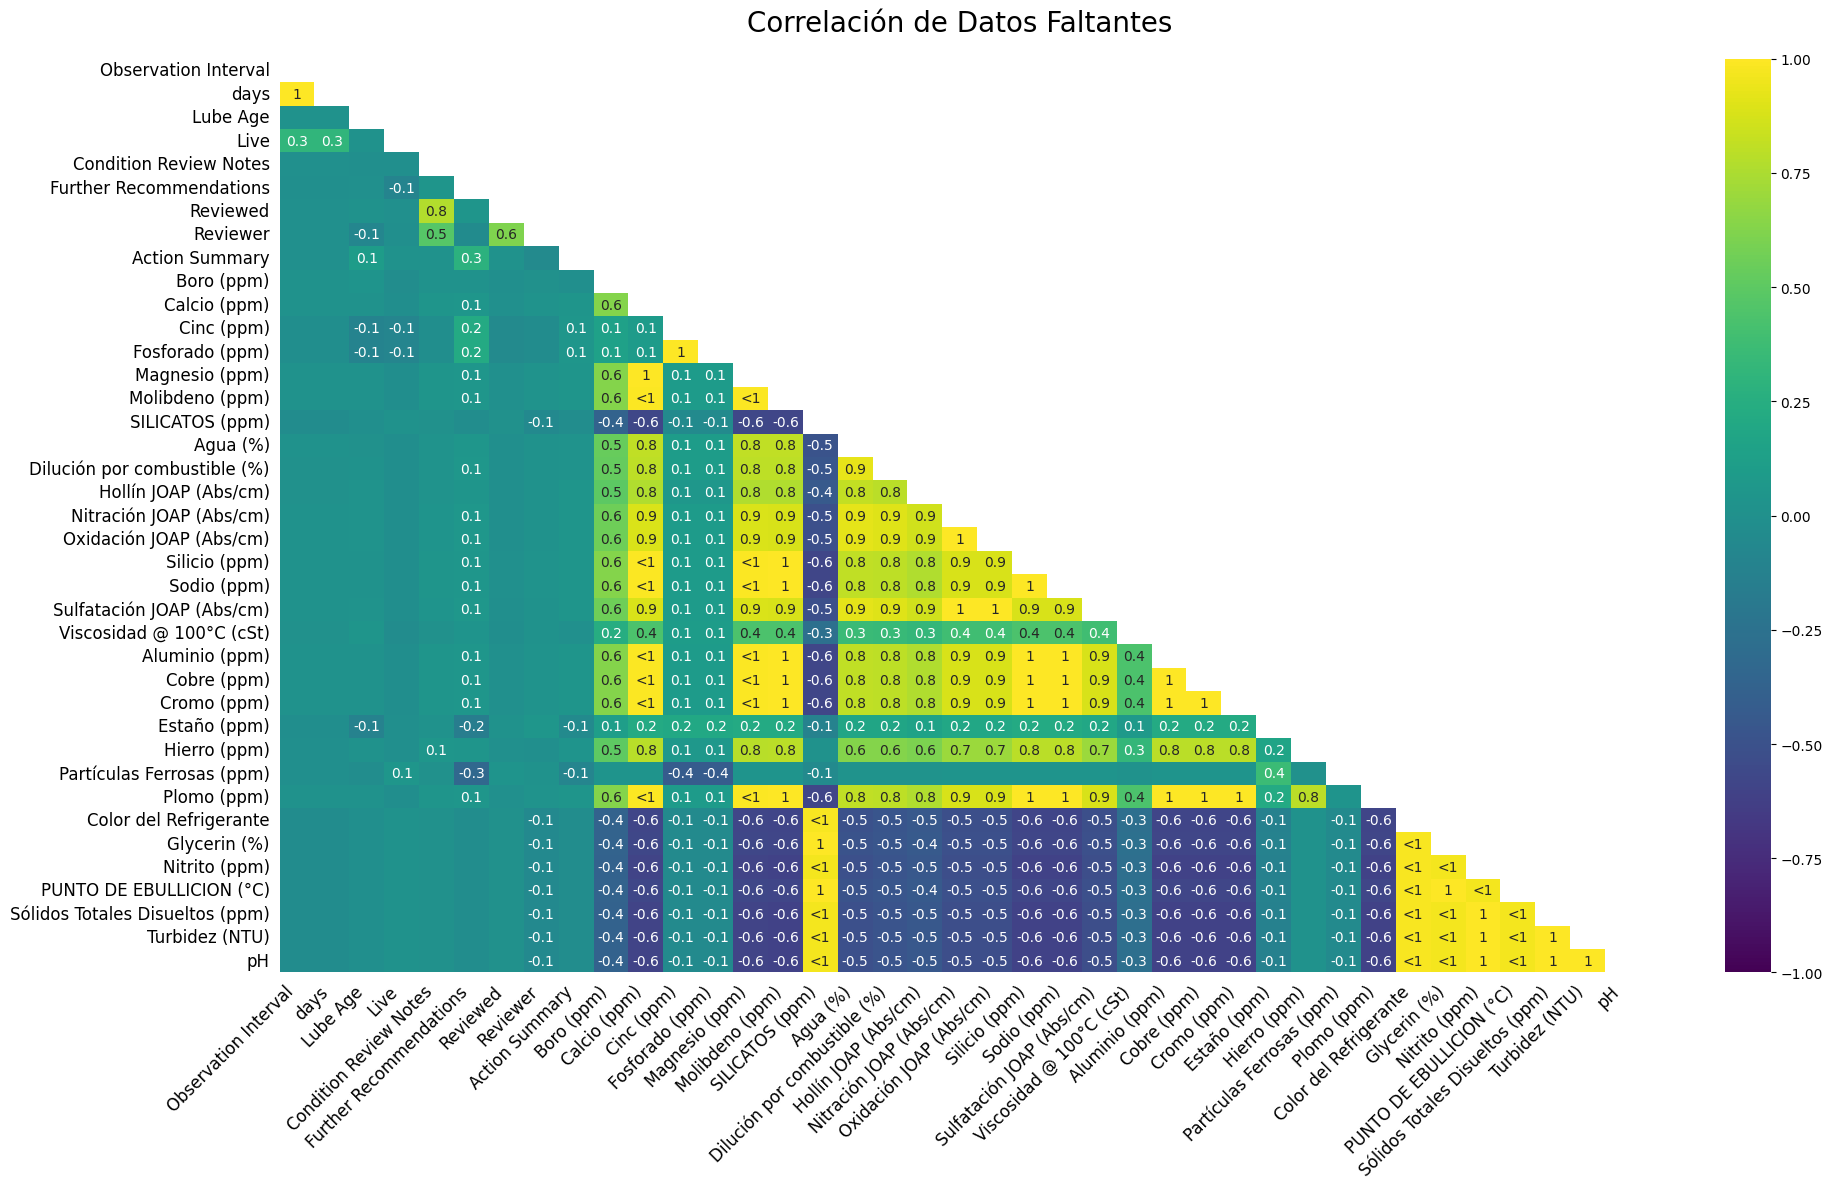

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16, 10), dpi=200)

ax = msno.heatmap(
    data,
    cmap="viridis",     # paleta profesional
    fontsize=12         # etiqueta de celdas más nítida
)

ax.set_title(
    "Correlación de Datos Faltantes",
    fontsize=20,
    pad=20
)

ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

* Hay bloques de columnas con correlaciones cercanas a 1.0, lo que indica que faltan juntas porque pertenecen al mismo proceso o análisis de laboratorio.
* El grupo de variables de metales y contaminantes (Calcio, Zinc, Magnesio, etc.) forma un bloque claro: si falta una, faltan todas.
* Las variables del paquete JOAP (Hollín, Nitración, Oxidación, Sulfatación) también muestran correlaciones casi perfectas entre sí.
* Existen correlaciones negativas entre algunos bloques, lo que indica que ciertos análisis rara vez faltan al mismo tiempo; provienen de procesos distintos.
* Algunas variables administrativas (como Observation Interval o days) muestran correlaciones bajas, indicando faltantes independientes.
* En resumen, los faltantes no son aleatorios: se agrupan por módulos de análisis, lo cual tiene impacto en la imputación, el modelado, y el diagnóstico.

## Parte II: Entendimiento de los datos

* Descripción de estadisticas basicas
* Análisis de distribucion de los datos
* Distribuciones frente a las categorias de la variable objetivo
* Feature importance
* Adición de nueva información

In [26]:
data.describe()

,Meter Reading,All Time Meter Reading,Component Age,Observation Interval,days,Lube Age,Live,Added,Boro (ppm),Calcio (ppm),...,Plomo (ppm),Color del Refrigerante,Glycerin (%),Nitrito (ppm),PUNTO DE EBULLICION (°C),Sólidos Totales Disueltos (ppm),Turbidez (NTU),pH,Titanio (ppm),Vanadio (ppm)
count,4297.000000,4297.00000,4297.000000,4273.000000,4273.000000,114.000000,4237.000000,4297.0,4112.000000,4219.000000,...,4221.000000,27.0,26.000000,28.000000,26.000000,28.000000,28.000000,28.000000,0.0,0.0
mean,37718.445041,40323.21411,8605.917747,246.894533,16.265621,7222.688421,8679.136592,0.0,58.141029,2149.858808,...,1.099069,0.0,48.443077,1751.428571,106.584615,914.571429,21.607143,9.453571,NaN,NaN
std,24265.299867,24727.10970,7865.818600,407.557769,15.205517,3579.832924,7848.997992,0.0,39.746011,865.738186,...,2.094020,0.0,1.214311,171.047195,0.242804,184.793865,3.993878,0.705262,NaN,NaN
min,0.000000,0.00000,0.000000,0.000000,1.000000,285.490000,0.000000,0.0,0.000000,1.660000,...,0.000000,0.0,45.700000,1400.000000,106.100000,605.000000,20.000000,8.200000,NaN,NaN
25%,15113.480000,17012.62000,3712.030000,100.030000,7.000000,4116.575000,3853.400000,0.0,35.210000,1607.000000,...,0.000000,0.0,47.637500,1630.000000,106.400000,790.250000,20.000000,8.875000,NaN,NaN
50%,39790.300000,42576.53000,7442.050000,195.100000,13.000000,7426.295000,7477.100000,0.0,60.260000,1804.000000,...,0.780000,0.0,48.775000,1750.000000,106.650000,897.000000,20.000000,9.650000,NaN,NaN
75%,59400.140000,61160.00000,11850.940000,316.130000,22.000000,10378.597500,11835.370000,0.0,87.397500,2393.000000,...,1.120000,0.0,49.315000,1880.000000,106.775000,992.000000,20.000000,10.100000,NaN,NaN
max,86467.570000,88527.24000,64709.850000,13231.070000,152.000000,16105.060000,64709.850000,0.0,395.440000,5411.000000,...,60.320000,0.0,50.180000,2000.000000,107.000000,1340.000000,33.000000,10.500000,NaN,NaN


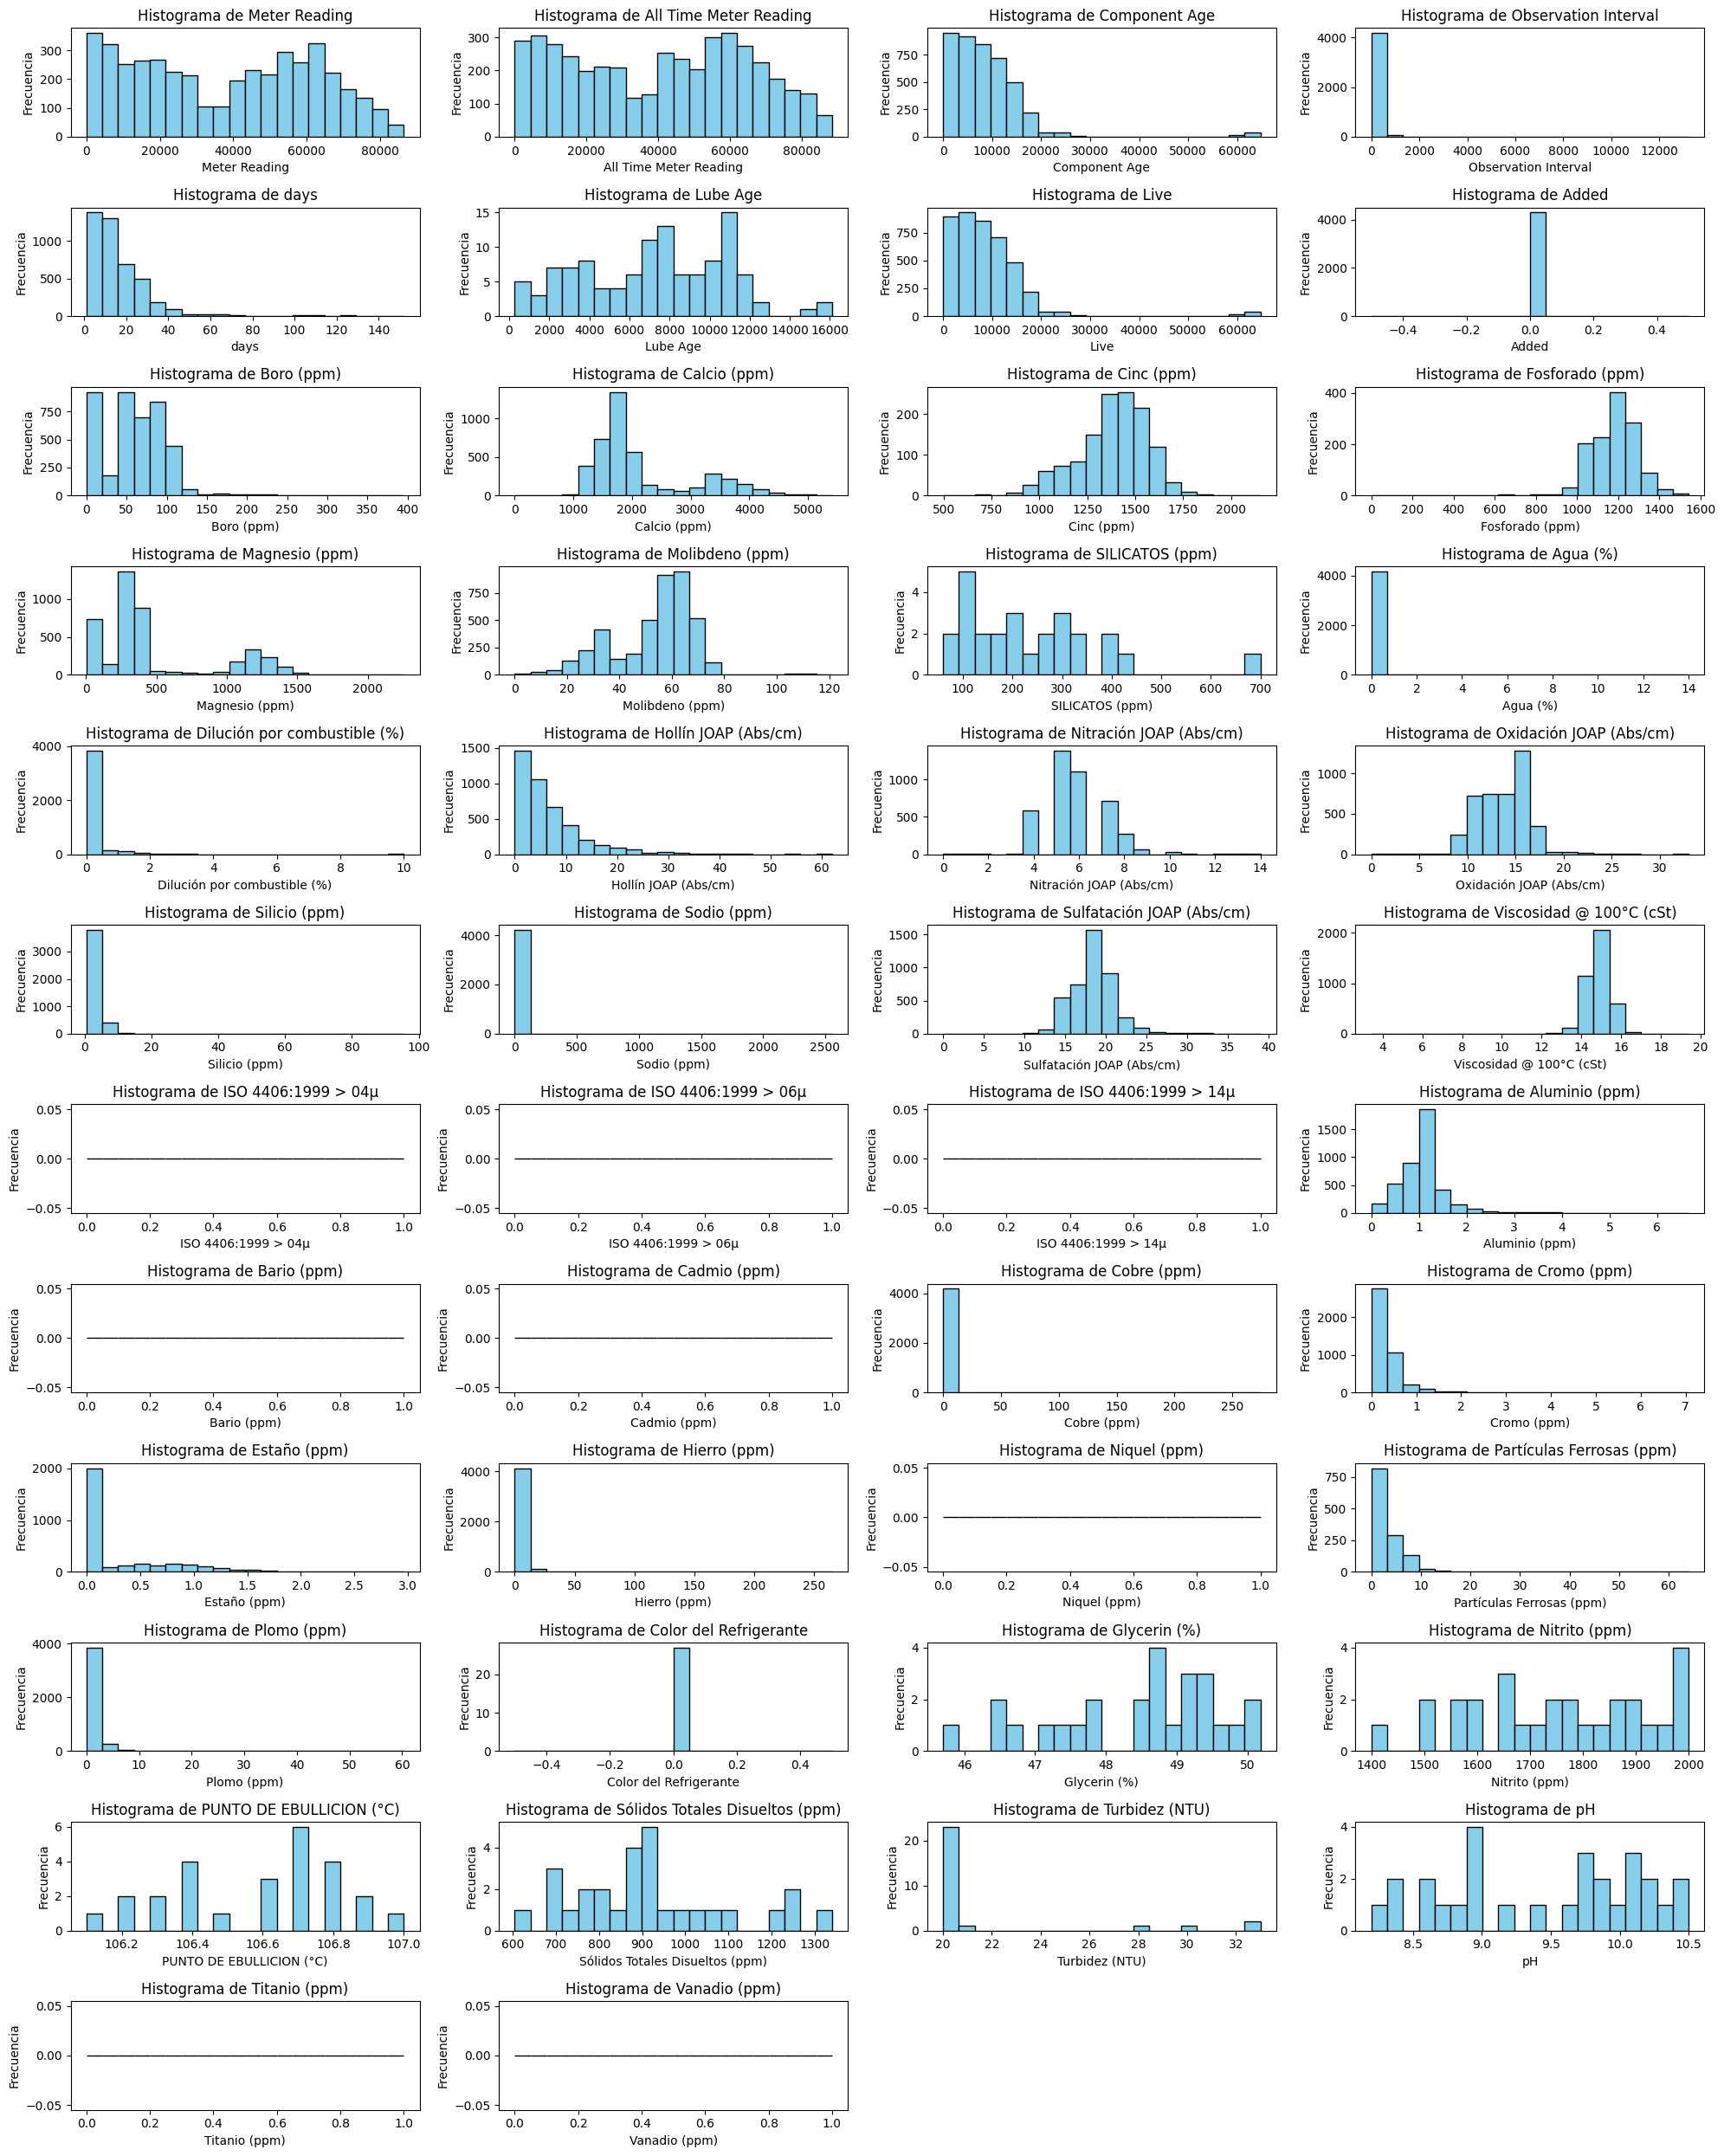

In [42]:
numerical_columns = data.select_dtypes(include=['int64',"float64"]).columns

# Determinar el tamaño de la cuadrícula
n_cols = 4
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols  # Redondeo hacia arriba para que haya suficiente espacio

# Crear la figura y los ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 25))
axes = axes.flatten()  # Aplanar los ejes para iterar sobre ellos fácilmente

# Generar un histograma para cada columna numérica
for i, col in enumerate(numerical_columns):
    axes[i].hist(data[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histograma de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Eliminar cualquier gráfico extra (en caso de que haya más subplots que columnas)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar el espaciado entre gráficos
plt.tight_layout()
plt.show()

* La mayoría de las variables están fuertemente sesgadas a la derecha.
  * La mayoría de las variables muestran distribuciones fuertemente sesgadas a la derecha.
  * Hay colas largas y presencia evidente de outliers extremos en múltiples variables (metales, JOAP, sólidos disueltos, sodio, silicio, etc.).
  * Esto sugiere procesos con valores excepcionales pero poco frecuentes, típicos de análisis de aceite contaminado o en falla.
* Outliers extremos: hay valores aislados muy altos en varios contaminantes y lecturas temporales; se debe verificar si representan fallas reales o errores de medición.
* Variables con valores casi nulos o detección limitada: varios metales (Bario, Cadmio, Níquel, Vanadio, Titanio, etc.) concentran la mayoría de observaciones en 0-cercano a 0 con pocos valores detectables → posible límite de detección del instrumento
* Histogramas planos o vacíos indican alta falta de datos o constantes: ISO 4406 y algunas trazas muestran prácticamente ninguna variación, esto debido a que se trata de datos faltantes en su mayoria.
* Las variables relacionadas con tiempo o uso del equipo tienen gran dispersión.

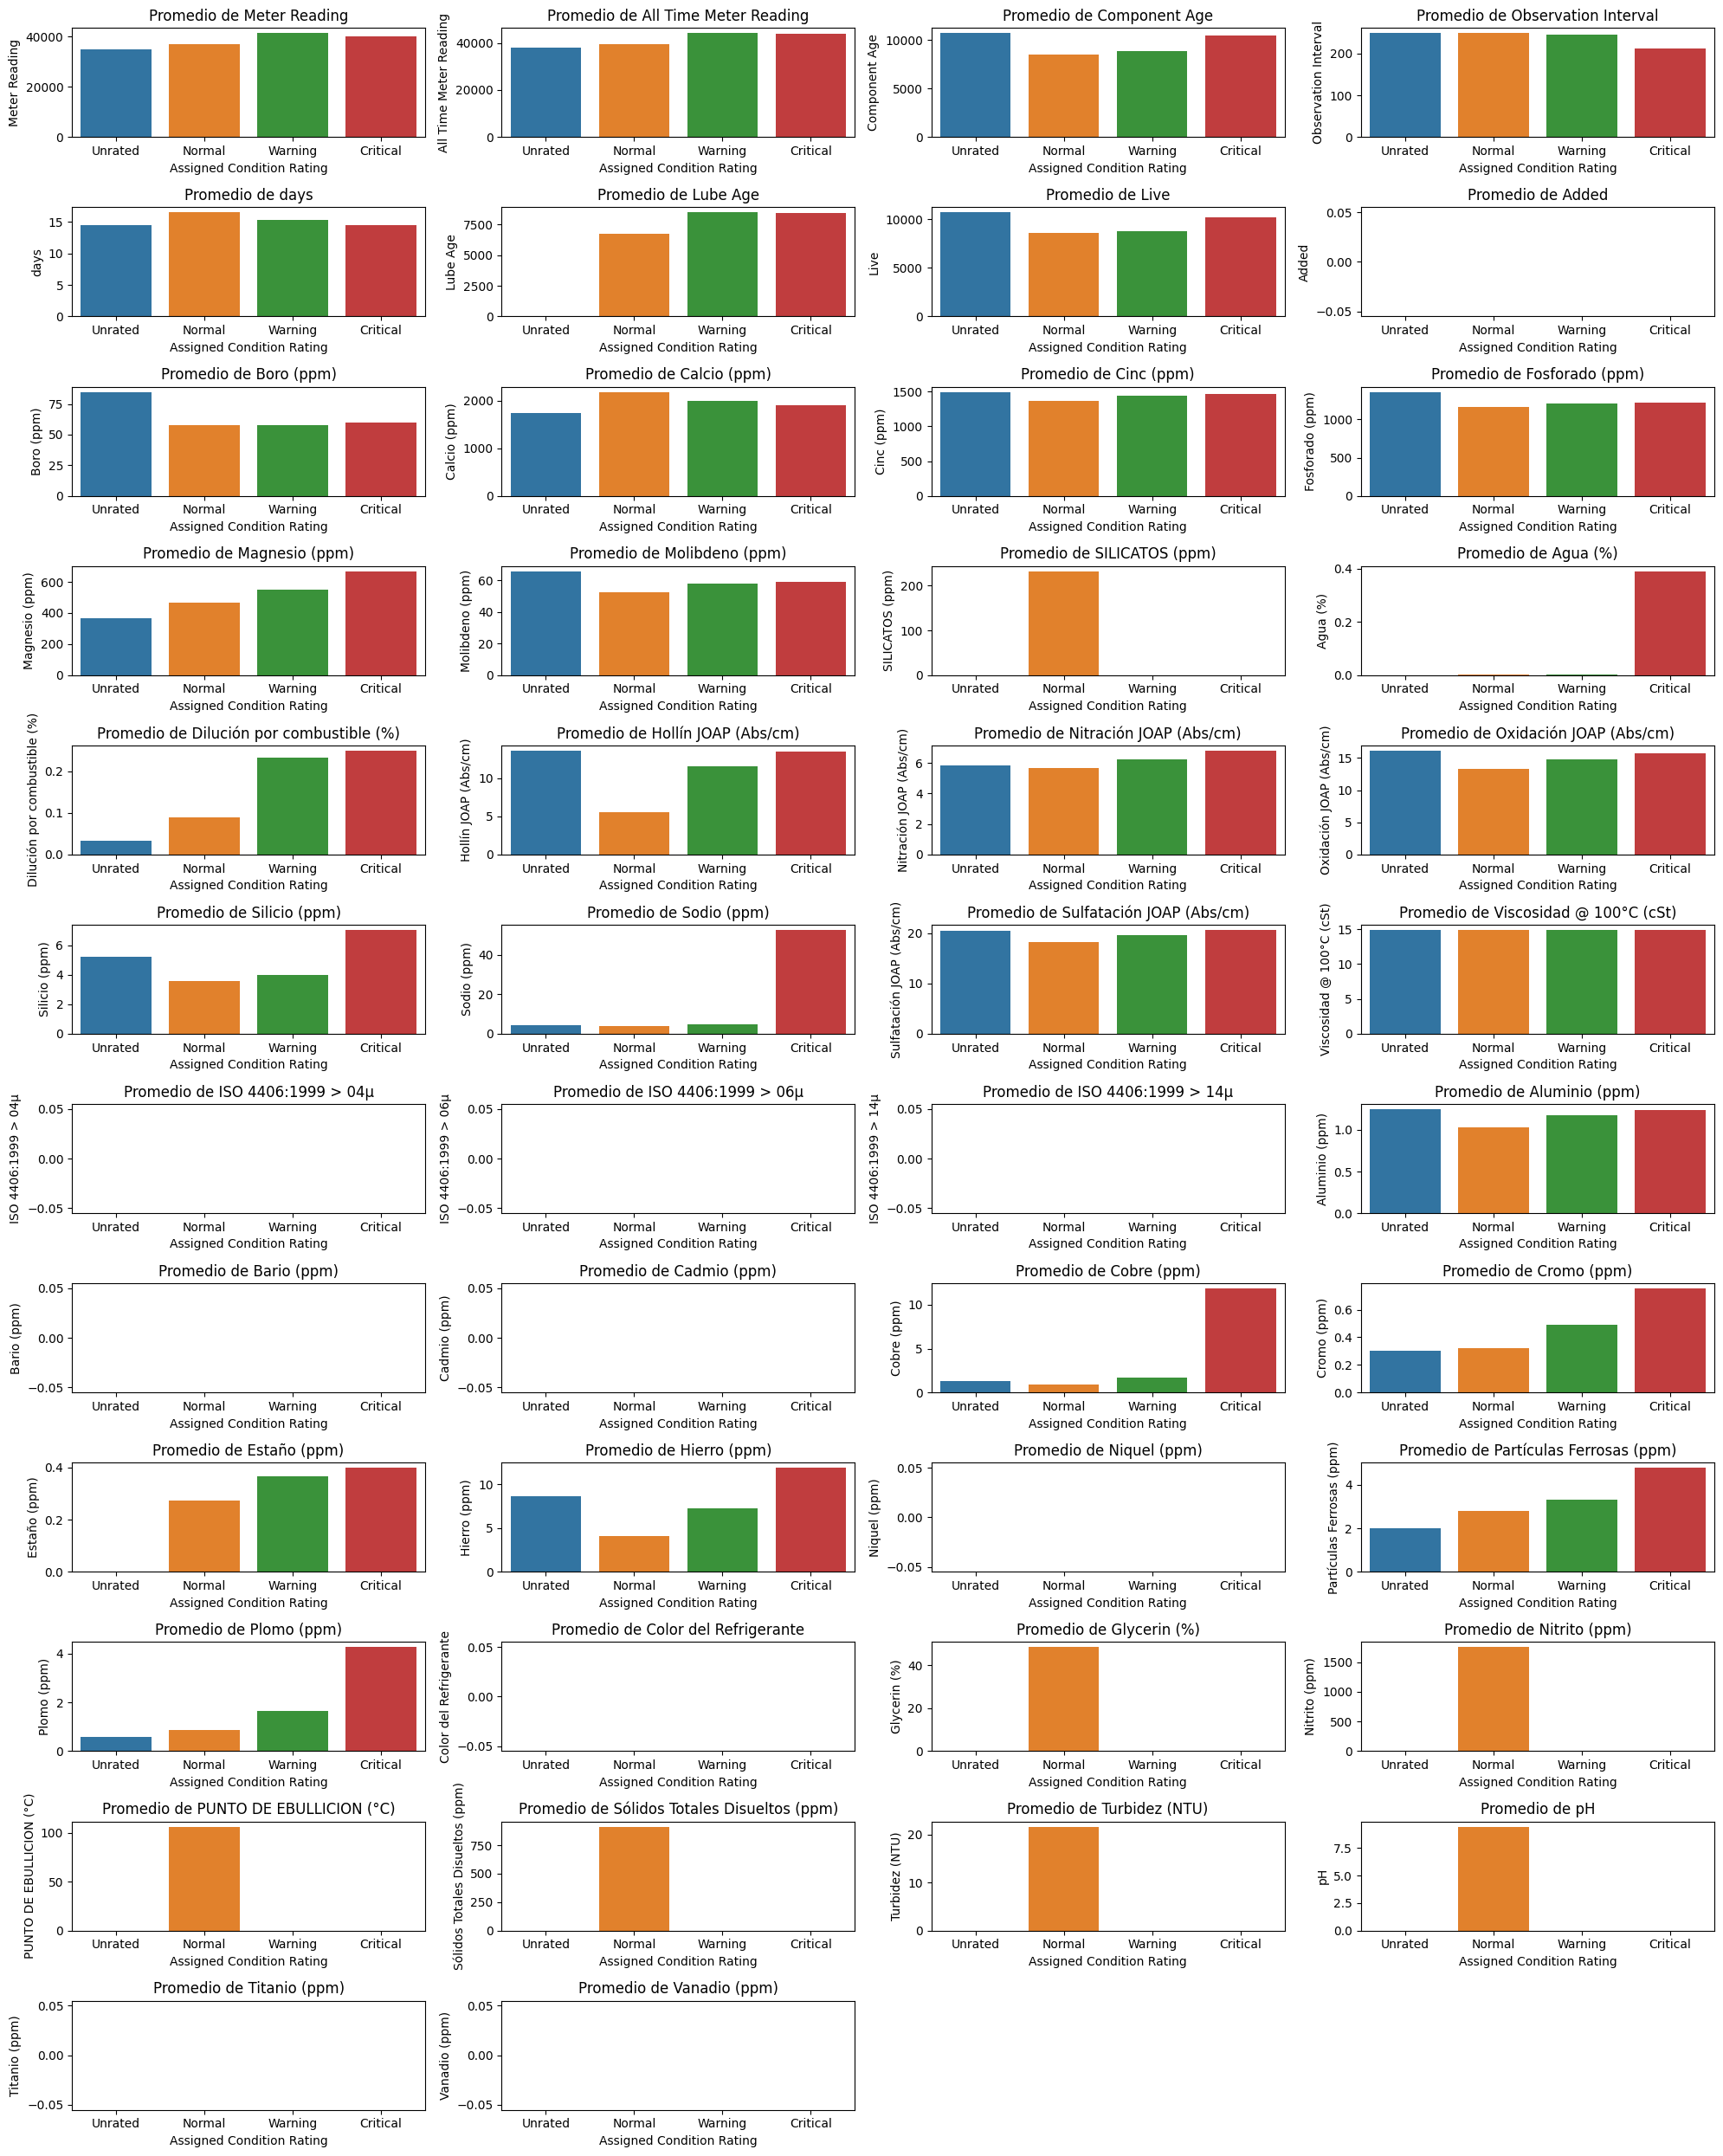

In [39]:
import seaborn as sns
plt.figure(figsize=(20, 25))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(12, 4, i)  
    sns.barplot(x='Assigned Condition Rating', y=col, data=data, errorbar=None, hue='Assigned Condition Rating')
    plt.title(f'Promedio de {col}')
    plt.xlabel('Assigned Condition Rating')
    plt.ylabel(col)
    plt.xticks(rotation=0)

plt.tight_layout()  
plt.show()

* Incremento progresivo hacia “Critical”: En la mayoría de los parámetros (metales, JOAP, sólidos, viscosidad, partículas), los valores promedio aumentan al pasar de Normal → Warning → Critical, validando la coherencia del sistema de clasificación. Esta variables terminan siendo fuertes candidatos a ser indicadores tempranos de desgaste o contaminación.
* JOAP (Hollín, Oxidación, Nitración, Sulfatación): Exhiben el patrón más consistente y marcado: valores significativamente más altos en Warning y, sobre todo, Critical. Son variables clave para modelar condición del aceite.
* Algunos metales con valores muy bajos: Muchos permanecen en cero o valores muy bajos en todas las categorías, lo cual limita su valor discriminante para estratificación de condición.


## Parte III: Técnicas de limpieza

* Rango de los datos y validez
* Faltantes y coherencia de los tipos de datos
* Outliers y justificar si se deben o no eliminar o imputar
* Correlaciones entre las variables

Ante los hallazgos de esta etapa se deben plantear alternativas de tratamiento (Eliminación o imputación)

In [23]:
# Se eliminan Variabes no necesarias
data_cleaned = data.copy()
data_cleaned = data_cleaned.dropna(axis=1, how='all')
data_cleaned = data_cleaned.drop(
	columns=[
		'Color del Refrigerante','Glycerin (%)','Nitrito (ppm)','PUNTO DE EBULLICION (°C)',
		'Sólidos Totales Disueltos (ppm)','Turbidez (NTU)','pH','Added','Lube Drained','Live',
		'Lube Age','days','Observation Interval','Component Age', 'All Time Meter Reading',
		'Meter Reading','Observation Code','Observation Date', 'Observation Type','Connection Code',
		'Lubricant','Component Profile','Location','Component ID','SILICATOS (ppm)','Asset ID'
	],
	errors='ignore'
)

## ¿Por qué eliminamos estas columnas del dataset?

En esta etapa del proceso de limpieza y preparación de datos, se eliminan múltiples columnas utilizando `data.drop()` con el objetivo de optimizar el análisis y evitar ruido en los modelos posteriores. Las razones principales son:

### 1. Variables irrelevantes para el análisis actual
Algunas columnas no aportan información útil para el estudio de condición del lubricante de los motores diesel, ya sea porque:
- Representan metadatos administrativos
- Son información redundante
- No tienen relación directa con las variables físico-químicas a analizar

Ejemplos:
- `Added`, `Lube Drained`, `Live`,`Lube Age`
- `Observation Date`, `Observation Code`, `Observation Type`,`Observation Interval`, `Meter Reading`,`All Time Meter Reading`
- `Component ID`, `Location`, `Asset ID`,`Connection Code','Lubricant`,`Component Profile`,`Component Age`,`All Time Meter Reading`

Estas columnas no contienen informacion relevante que permita la identificacion de modos de fallas generadas en el analisis de aceite , es por esta razon que las variables son excluidas de dataset con el cual se trabajara. En algunos caso como `Lube Drained`,`Lube Age`,`Component Age`si fueran relevantes incluirlas dentro del analisis , sin embargo , en consultas con el cliente este ha expresado que en esta fase los datos contenidos en las columnas mencionadas no son confiables debido a problemas de sincronizacion entre diversos software que tienen en operacion ,se espera que en posibles desarrollos posteriores ya se cuente con esta informacion e incluirlas como variables de entreamiento al modelo. 


### 2. Variables que no aplican al análisis de aceite en motores diesel   
En el dataset se incluyen parámetros que pertenecen a otra categoría de análisis (por ejemplo, refrigerantes).

Ejemplo:
- `Color del Refrigerante`
- `Nitrito (ppm)`
- `PUNTO DE EBULLICION (°C)`
- `Sólidos Totales Disueltos (ppm)`
- `Turbidez (NTU)`
- `SILICATOS (ppm)`

Como el enfoque está en aceite y contaminantes metálicos, estos campos no son relevantes.Los prediectores contenidos en esta lsitas son comunmente utilizados en el analsisi de refrigerante. para el analisis de aceite usado (AAU) no son relevantes. 

### 4. Reducción de dimensionalidad  
Eliminar columnas innecesarias:
- Reduce el peso del dataset  
- Acelera el procesamiento  
- Evita sobreajuste en modelos predictivos  
- Mejora la interpretabilidad  


In [24]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4297 entries, 0 to 4296
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Flota                         4297 non-null   object        
 1   Observation Rating            4297 non-null   object        
 2   Trakka Rating                 4297 non-null   object        
 3   Assigned Condition Rating     4297 non-null   object        
 4   Condition Review Notes        4275 non-null   object        
 5   Further Recommendations       1453 non-null   object        
 6   Fault Effect                  4297 non-null   object        
 7   Reviewed                      4284 non-null   datetime64[ns]
 8   Reviewer                      4263 non-null   object        
 9   Action Summary                356 non-null    object        
 10  Boro (ppm)                    4112 non-null   float64       
 11  Calcio (ppm)                  

In [18]:
# Se agrupan las varibles segun la metodologia SACODE 

Salud = data[['Boro (ppm)', 'Calcio (ppm)', 'Cinc (ppm)', 'Fosforado (ppm)', 'Magnesio (ppm)', 'Molibdeno (ppm)', 'Nitración JOAP (Abs/cm)', 'Oxidación JOAP (Abs/cm)', 'Sulfatación JOAP (Abs/cm)','Sodio (ppm)']]
Desgaste = data[['Aluminio (ppm)', 'Cobre (ppm)', 'Cromo (ppm)', 'Estaño (ppm)', 'Hierro (ppm)', 'Partículas Ferrosas (ppm)', 'Plomo (ppm)','Oxidación JOAP (Abs/cm)' ]]
Contaminacion = data[['Agua (%)', 'Dilución por combustible (%)', 'Hollín JOAP (Abs/cm)', 'Silicio (ppm)','Sodio (ppm)','Aluminio (ppm)']]

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("\n=== Tipos de datos iniciales ===")
print(data.dtypes)

print("\n=== Rango (mínimo y máximo) de variables numéricas ===")
rangos = data_cleaned.select_dtypes(include=[np.number]).agg(['min','max']).T
print(rangos)

print("\n=== Porcentaje de faltantes por columna ===")
faltantes = data_cleaned.isna().mean().sort_values(ascending=False)*100
print(faltantes)

posibles_numericas = []
for col in data_cleaned.columns:
    if data_cleaned[col].dtype == 'object':
        try:
            pd.to_numeric(data_cleaned[col].astype(str).str.replace(',','.'), errors='raise')
            posibles_numericas.append(col)
        except:
            pass

print("\n=== Posibles columnas numéricas mal tipificadas como object ===")
print(posibles_numericas)


print("\n=== Detección de Outliers  ===")

def detectar_outliers(col):
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    return ((col < lower) | (col > upper)).sum()

outliers_resumen = {}
for col in data_cleaned.select_dtypes(include=[np.number]).columns:
    outliers_resumen[col] = detectar_outliers(data_cleaned[col])

outliers_df = pd.DataFrame.from_dict(outliers_resumen, orient='index', columns=['Outliers'])
print(outliers_df.sort_values('Outliers', ascending=False))

# === Boxplots automáticos por columna (para inspección visual) ===
for col in data_cleaned.select_dtypes(include=[np.number]).columns:
    # Skip columns with all NaN or no valid data
    if data_cleaned[col].dropna().empty:
        continue



numericas = data_cleaned.select_dtypes(include=[np.number])

print("\n=== Matriz de correlaciones ===")
corr = numericas.corr()
print(corr)







=== Tipos de datos iniciales ===
Flota                                   object
Observation Rating                      object
Trakka Rating                           object
Assigned Condition Rating               object
Condition Review Notes                  object
Further Recommendations                 object
Fault Effect                            object
Reviewed                        datetime64[ns]
Reviewer                                object
Action Summary                          object
Boro (ppm)                             float64
Calcio (ppm)                           float64
Cinc (ppm)                             float64
Fosforado (ppm)                        float64
Magnesio (ppm)                         float64
Molibdeno (ppm)                        float64
Agua (%)                               float64
Dilución por combustible (%)           float64
Hollín JOAP (Abs/cm)                   float64
Nitración JOAP (Abs/cm)                float64
Oxidación JOAP (Abs/cm)   

### Tratamiento de datos flatantes 

Con base en los  datos faltantes identifiados , se concuenrda una reunion con el clieente en donde se definen las siguintes accion bajo los datos faltantes entregada. 

| Variable | % Faltantes | ¿Por qué se genera? | ¿Se requiere para el desarrollo del modelo? | ¿Se elimina? | ¿Qué tratamiento se le dará a los datos faltantes? |
|---------|--------------|----------------------|---------------------------------------------|--------------|----------------------------------------------------|
| Action Summary | 91.71515 | Debido a que no todos los analistas llenan el listado de acciones a realizar y la documentan en el ERP; para esto se utiliza otra BD | No | Sí | Se elimina la columna del dataframe |
| Partículas Ferrosas (ppm) | 70.351408 | No en todos los motores se mide esta variable por altos tiempos de procesamiento en laboratorio | Sí | Sí | El cliente aprueba eliminar la variable; no es medición rutinaria |
| Fosforado (ppm) | 69.979055 | Dato faltante por inconsistencias operativas | Sí | No | Imputación por mediana; es un aditivo base del aceite |
| Cinc (ppm) | 69.979055 | Problemas de digitación o identificación en laboratorio | Sí | No | Imputación por mediana; pertenece a aditivos del aceite |
| Further Recommendations | 66.185711 | No todos los analistas llenan este campo; trazabilidad se realiza en otro software | No | Sí | Se elimina la columna del dataframe |
| Estaño (ppm) | 28.48499 | En años anteriores no se medía; ahora sí se incluye como rutina | Sí | No | Imputación por mediana |
| Viscosidad @ 100°C (cSt) | 7.679777 | Problemas de digitación o identificación por baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Boro (ppm) | 4.305329 | Problemas en digitación o identificación del aditivo | Sí | No | Imputación por mediana |
| Hollín JOAP (Abs/cm) | 3.002094 | Problemas de digitación o baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Dilución por combustible (%) | 2.746102 | Problemas de digitación o baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Agua (%) | 2.466837 | Problemas de digitación o baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Oxidación JOAP (Abs/cm) | 2.280661 | Problemas de digitación o baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Nitración JOAP (Abs/cm) | 2.280661 | Problemas de digitación o baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Sulfatación JOAP (Abs/cm) | 2.280661 | Problemas de digitación o baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Calcio (ppm) | 1.81522 | Problemas de digitación o identificación por baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Magnesio (ppm) | 1.81522 | Problemas de digitación o identificación por baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Molibdeno (ppm) | 1.768676 | Problemas de digitación o identificación por baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Silicio (ppm) | 1.768676 | Problemas de digitación o identificación por baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Sodio (ppm) | 1.768676 | Problemas de digitación o identificación por baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Aluminio (ppm) | 1.768676 | Problemas de digitación o identificación por baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Cromo (ppm) | 1.768676 | Problemas de digitación o identificación por baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Cobre (ppm) | 1.768676 | Problemas de digitación o identificación por baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Plomo (ppm) | 1.768676 | Problemas de digitación o identificación por baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Hierro (ppm) | 1.117058 | Problemas de digitación o identificación por baja disponibilidad del instrumento | Sí | No | Imputación por mediana |
| Reviewer | 0.79125 | Errores de sincronización del software ERP | No | Sí | Se elimina la columna |
| Condition Review Notes | 0.511985 | No todos los analistas llenan el campo; trazabilidad se realiza en otro software | No | Sí | Se elimina la columna |
| Reviewed | 0.302537 | Errores de sincronización del software ERP | No | Sí | Se elimina la columna |
| Assigned Condition Rating | 0 | No se registran faltantes | Sí | No | Se mantiene |
| Fault Effect | 0 | No se registran faltantes | Sí | No | Se mantiene |
| Trakka Rating | 0 | No se registran faltantes | No | Sí | Variable no relevante para el modelo |
| Observation Rating | 0 | No se registran faltantes | No | Sí | Variable no relevante para el modelo |
| Flota | 0 | No se registran faltantes | Sí | No | Se mantiene |




## Rango de Valores numericos de las variable en el dataset y validez 

Una vez definidos los criterios para el tratamiento de los datos faltantes, se procede a revisar los rangos de valores observados durante la exploración del dataset proporcionado por el cliente. A partir de este análisis, se establecen las siguientes conclusiones. 



| Variable                       | Mínimo | Máximo | Comentario                                                     |
|--------------------------------|--------|--------|-----------------------------------------------------------------|
| Boro (ppm)                     | 0      | 395.44 | Válido                                                          |
| Calcio (ppm)                   | 1.66   | 5411   | No válido, valores de calcio presentan niveles >1000, posible outlier |
| Cinc (ppm)                     | 495.99 | 2154   | No válido, valores de cinc presentan niveles >1000, posible outlier   |
| Fosforado (ppm)                | 0      | 1542   | No válido, valores de fósforo presentan niveles >1000, posible outlier |
| Magnesio (ppm)                 | 3.16   | 2256   | Válido                                                          |
| Molibdeno (ppm)                | 0      | 121.13 | Válido                                                          |
| Agua (%)                       | 0      | 14     | Válido                                                          |
| Dilución por combustible (%)   | 0      | 10     | Válido                                                          |
| Hollín JOAP (Abs/cm)           | 0      | 62     | Válido                                                          |
| Nitración JOAP (Abs/cm)        | 0      | 14     | Válido                                                          |
| Oxidación JOAP (Abs/cm)        | 0      | 33     | Válido                                                          |
| Silicio (ppm)                  | 0.55   | 95.54  | Válido                                                          |
| Sodio (ppm)                    | 0.17   | 2556   | Válido                                                          |
| Sulfatación JOAP (Abs/cm)      | 0      | 39     | Válido                                                          |
| Viscosidad @ 100°C (cSt)       | 3.431  | 19.4   | Válido                                                          |
| Aluminio (ppm)                 | 0      | 6.66   | Válido                                                          |
| Cobre (ppm)                    | 0.01   | 274.2  | Válido                                                          |
| Cromo (ppm)                    | 0      | 7.07   | Válido                                                          |
| Estaño (ppm)                   | 0      | 2.96   | Válido                                                          |
| Hierro (ppm)                   | 0      | 265.38 | Válido                                                          |
| Plomo (ppm)                    | 0      | 60.32  | Válido                                                          |




## Tratamiento a Outlier 

A partir de los outliers identificados mediante el método del rango intercuartílico (IQR), utilizando el umbral estándar de 1.5 veces el rango, se procede a cuantificar la cantidad de valores atípicos detectados en cada variable. Con esta información, se definen las acciones a seguir, las cuales serán acordadas y validadas conjuntamente con el cliente

| Variable                          | # Outlier | ¿Se deben eliminar o imputar?                                      |
|----------------------------------|-----------|--------------------------------------------------------------------|
| Magnesio (ppm)                   | 947       | Sí, se deben imputar por valores de mediana, posible cambio en la formulación del aceite                         |
| Dilución por combustible (%)     | 530       | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Calcio (ppm)                     | 455       | Sí, se deben imputar por valores de mediana, posible cambio en la formulación del aceite                        |
| Plomo (ppm)                      | 414       | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Aluminio (ppm)                   | 357       | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Cobre (ppm)                      | 340       | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Hierro (ppm)                     | 336       | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Cromo (ppm)                      | 297       | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Silicio (ppm)                    | 263       | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Sodio (ppm)                      | 258       | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Hollín JOAP (Abs/cm)             | 200       | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Estaño (ppm)                     | 102       | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Molibdeno (ppm)                  | 88        | Sí, se deben imputar por valores de mediana,, posible cambio en la formulación del aceite                        |
| Sulfatación JOAP (Abs/cm)        | 83        | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Oxidación JOAP (Abs/cm)          | 68        | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Viscosidad @ 100°C (cSt)         | 60        | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Boro (ppm)                       | 41        | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Nitración JOAP (Abs/cm)          | 37        | No, corresponden a fallas; no se deben eliminar ni imputar        |
| Fosforado (ppm)                  | 21        | Sí, se deben imputar por valores de mediana, posible cambio en la formulación del aceite                        |
| Cinc (ppm)                       | 20        | Sí, se deben imputar por valores de mediana, posible cambio en la formulación del aceite                        |
| Agua (%)                         | 17        | No, corresponden a fallas; no se deben eliminar ni imputar        |

In [27]:
# Se eliminarn las variables con mayor cantidad de faltantes y no relevantes para el modelo segun lo conversado con el cliente
data_cleaned = data_cleaned.drop(
	columns=[
		'Action Summary','Partículas Ferrosas (ppm)','Further Recommendations','Reviewed',
		'Reviewer','Condition Review Notes','Trakka Rating','Observation Rating'
	],
	errors='ignore'
)

## Imputación de Datos 
De acuerdo a lo expuesto anteriormente , se decide imputar los varlores faltantes y los datos considerados como outlier en los cuales se acuerda con el cliente aplicar la imputacion de los valores, para esto se utiliza un imputados basado en el modelo K-Vecinos en donde se busca imputar los datos apartir de similaridad con las otras muestras tal como se plasma en la Parte I: Calidad de datos

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer


imputable_outliers = [
    "Magnesio (ppm)",
    "Calcio (ppm)",
    "Molibdeno (ppm)",
    "Fosforado (ppm)",
    "Cinc (ppm)"
]

no_imputar_outliers = [
    "Dilución por combustible (%)","Plomo (ppm)","Aluminio (ppm)","Cobre (ppm)",
    "Hierro (ppm)","Cromo (ppm)","Silicio (ppm)","Sodio (ppm)","Hollín JOAP (Abs/cm)",
    "Estaño (ppm)","Sulfatación JOAP (Abs/cm)","Oxidación JOAP (Abs/cm)",
    "Viscosidad @ 100°C (cSt)","Boro (ppm)","Nitración JOAP (Abs/cm)",
    "Agua (%)"
]


def flag_outliers_iqr_selective(df, cols):
    df_out = df.copy()

    for col in cols:
        Q1 = df_out[col].quantile(0.25)
        Q3 = df_out[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        # Solo marcar outliers en variables permitidas
        df_out.loc[(df_out[col] < lower) | (df_out[col] > upper), col] = np.nan

    return df_out


data_out = flag_outliers_iqr_selective(data_cleaned, imputable_outliers)




numeric_cols = data_cleaned.select_dtypes(include=np.number).columns


imputer = KNNImputer(n_neighbors=5, weights="distance")


data_imputed = pd.DataFrame(
    imputer.fit_transform(data_out[numeric_cols]),
    columns=numeric_cols
)


data_cleaned[numeric_cols] = data_imputed



Imputación selectiva completada según reglas de negocio.


<Axes: >

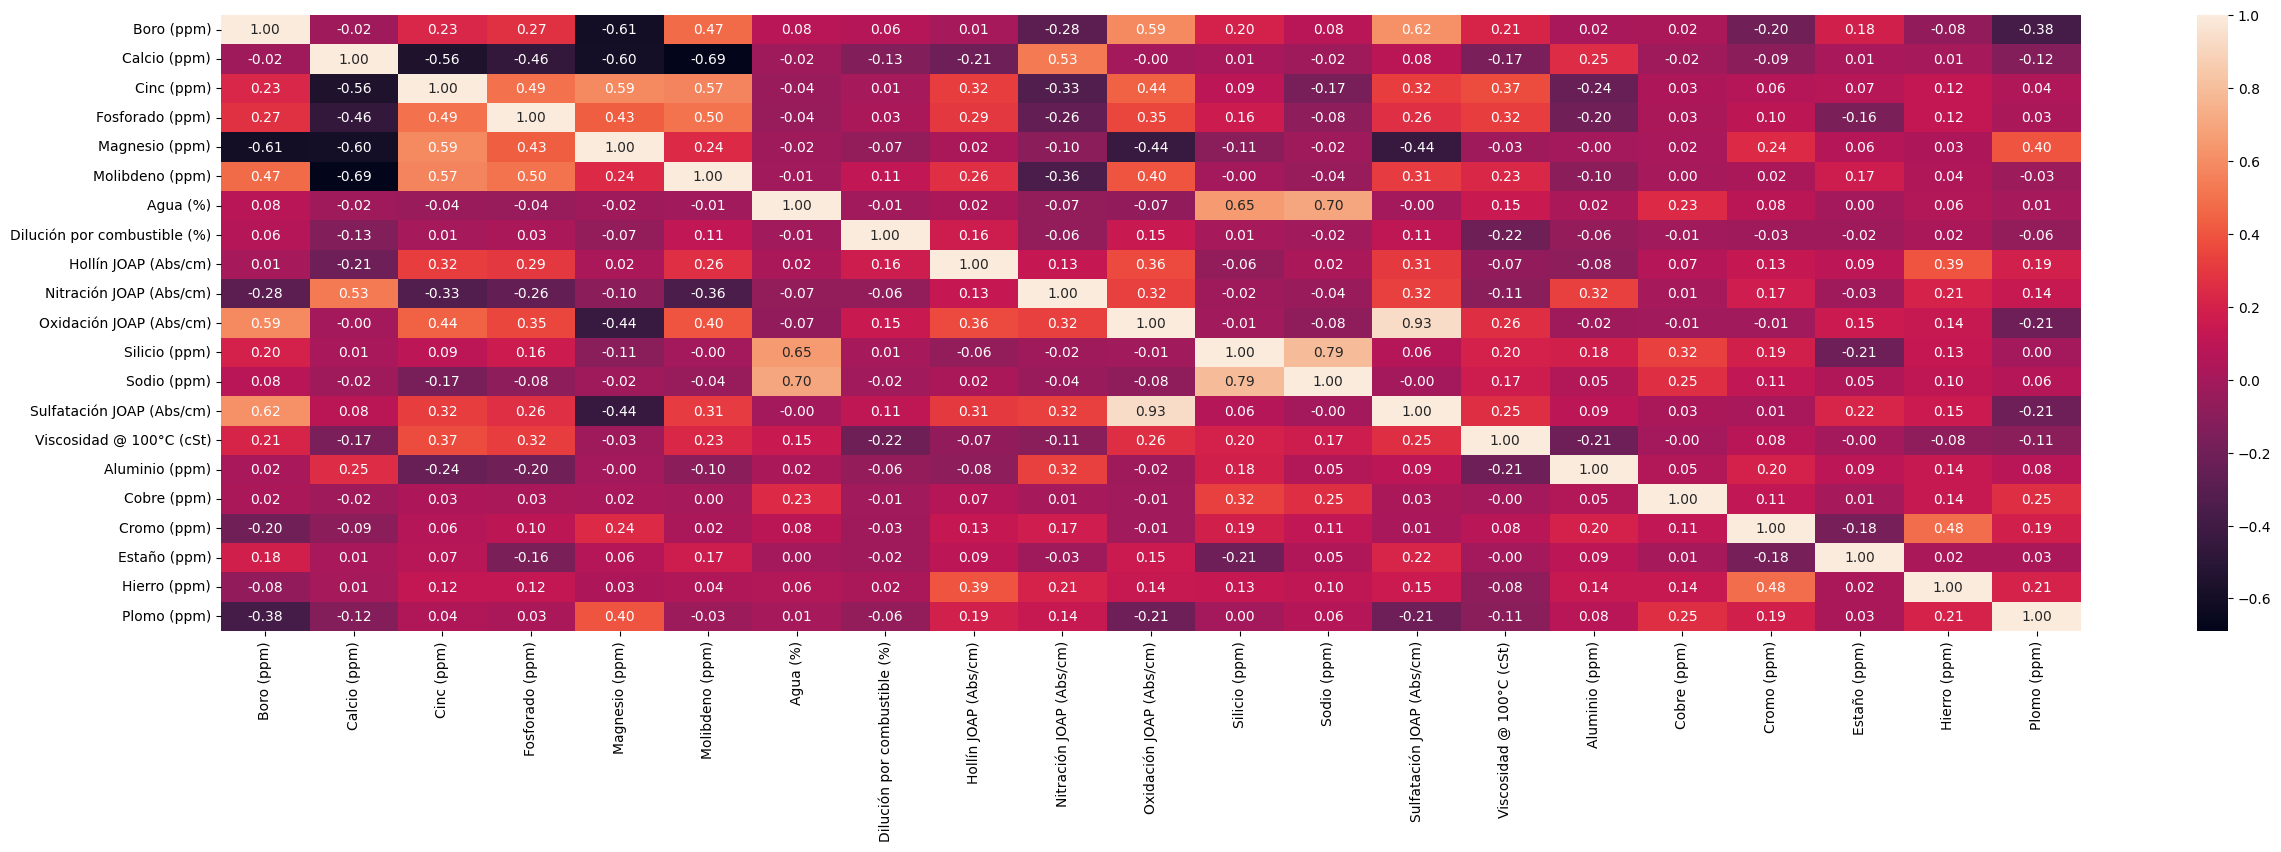

In [28]:
corr = data_cleaned.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(30,8))
sns.heatmap(corr, annot=True, fmt=".2f")

# Interpretación de la Matriz de Correlación  
### Análisis de Aceite de Motores Diesel 

La matriz de correlación permite identificar asociaciones lineales entre los distintos parámetros fisicoquímicos, de desgaste y contaminación del lubricante. El analisis de correlaciones para detectar redundancias entre variables, evaluar multicolinealidad y comprender relaciones físico-mecánicas relevantes entre mecanismos de falla. A continuacion se muestran los puntos claves identificados a partir del analisis de correlación. 

---

## 1. Metales de desgaste: 

### 1.1. Asociaciones fuertes entre metales relacionados con superficies ferrosas

- **Hierro (Fe)** correlaciona de manera positiva con:
  - **Silicio (Si): 0.39**  
  - **Cobre (Cu): 0.11**  
  - **Partículas ferrosas PQ: 0.22**

**Interpretación:**  
Esto indica desgaste abrasivo (Si → Fe), desgaste mixto Fe–Cu y coherencia entre mediciones ICP y PQ.La mayoria de componentes del motor estan compuestos de este material quimico. 

### 1.2. Correlaciones destacadas entre metales "no ferrosos"

- **Cinc (Zn)** correlaciona negativamente con **Calcio (Ca): −0.56**
- **Magnesio (Mg)** tiene correlación negativa con:
  - **Boro (B): −0.61**
  - **Calcio (Ca): −0.60**

**Interpretación:**  
Estas correlaciones indican diferencias en paquetes de aditivos entre aceites:  
- Ca y B suelen asociarse a detergentes.  
- Zn suele estar ligado a ZDDP (antidesgaste).  
Aditivos distintos → correlaciones opuestas.

### 1.3. Relaciones moderadas entre P–Zn–B

- Fosforo, Zinc y Boro presentan correlaciones entre **0.45–0.59**, reflejando consistencia en el sistema de aditivos ZDDP.

El **Plomo (Pb)** muestra correlaciones positivas con:

- **Cobre (Cu): 0.25**  
- **Hollín JOAP (Abs/cm): 0.19**  
- **Nitración JOAP (Abs/cm): 0.14**

**Interpretación:**

El Plomo y el Cobre suelen encontrarse en componentes lubricados formados por  (Pb–Sn–Cu). Por esto, sus correlaciones positivas sugieren:

1. **Desgaste conjunto de superficies de apoyo**  
   La correlación **Pb–Cu (0.25)** indica que cuando aumenta el desgaste de Cu, también lo hace el de Pb, lo cual es típico en fallas por desgaste hidrodinámico insuficiente, fatiga superficial o contaminación abrasiva en cojinetes.

2. **Relación entre desgaste y presencia de hollín**  
   La correlación **Pb–Hollín (0.19)** sugiere que niveles elevados de hollín pueden estar asociados con:
   - Incremento en la viscosidad del aceite,  
   - Formación de depósitos,  
   - Pérdida de lubricidad.  

   Estos factores deterioran la película lubricante y favorecen el desgaste de cojinetes que contienen Pb y Cu.




## 2. Indicadores de oxidación, nitración y hollín

### 2.1. Oxidación vs. Nitración vs. Sulfatación

- **Oxidación – Sulfatación: 0.93 (muy alta)**
- **Oxidación – Nitración: 0.32**
- **Nitración – Sulfatación: 0.32**

**Interpretación:**  
Estos parámetros representan procesos sinérgicos de degradación del aceite. La correlación 0.93 indica redundancia → posible eliminación de una variable en modelos predictivos para evitar multicolinealidad.

### 2.2. Hollín (Soot)

Correlaciones relevantes:
- **Viscosidad: 0.23**
- **Nitración: 0.13**
- **Sulfatación: 0.10**

**Interpretación:**  
El hollín contribuye al incremento de viscosidad y acelera la degradación del aceite.Ambos factores generan un incrmento en los predictores metalicos como puede obersarver lineas arribas. 



## 3. Parámetros de contaminación

### 3.1. Agua

- Presenta correlaciones muy bajas con la mayoría de las variables.

**Interpretación:**  
La humedad no está generando efectos significativos en esta población de muestras.

### 3.2. Silicio (Si)

- Correlación con:
  - **Hierro (0.39)**
  - **Cobre (0.32)**
  - **Cromo (0.11)**

**Interpretación:**  
Apunta a ingreso de contaminantes abrasivos (polvo) que incrementan el desgaste metálico.

### 3.3. Dilución por combustible (%)

- Correlación negativa con viscosidad (−0.21).

**Interpretación:**  
La dilución reduce la viscosidad, tal como se espera. Sin embargo, no muestra relaciones fuertes con metales, indicando control adecuado del fenómeno.



## 4. Propiedades del lubricante

### 4.1. Viscosidad @100°C

- Se relaciona con:
  - **Oxidación: 0.26**
  - **Sulfatación: 0.25**
  - **Nitración: 0.14**

**Interpretación:**  
El aumento de viscosidad está principalmente influenciado por procesos de oxidación térmica del aceite.



## 5. Recomendaciones para el modelo predictivo

### 5.1. Variables altamente correlacionadas (potencial multicolinealidad)

- **Oxidación – Sulfatación (0.93)**
- **Calcio – Magnesio (−0.60)**
- **Calcio – Cinc (−0.56)**


## Parte IV: Entendimiento de los datos
* Descripción de estadisticas basicas
* Análisis de distribucion de los datos
* Distribuciones frente a las categorias de la variable objetivo
* Feature importance
* Adición de nueva información

In [30]:
data_cleaned.describe()

,Boro (ppm),Calcio (ppm),Cinc (ppm),Fosforado (ppm),Magnesio (ppm),Molibdeno (ppm),Agua (%),Dilución por combustible (%),Hollín JOAP (Abs/cm),Nitración JOAP (Abs/cm),...,Silicio (ppm),Sodio (ppm),Sulfatación JOAP (Abs/cm),Viscosidad @ 100°C (cSt),Aluminio (ppm),Cobre (ppm),Cromo (ppm),Estaño (ppm),Hierro (ppm),Plomo (ppm)
count,4112.000000,4219.000000,1290.000000,1290.000000,4219.000000,4221.000000,4191.000000,4179.000000,4168.000000,4199.000000,...,4221.000000,4221.000000,4199.000000,3967.000000,4221.000000,4221.000000,4221.000000,3073.000000,4249.000000,4221.000000
mean,58.141029,2149.858808,1384.292349,1176.613814,485.093951,53.404196,0.017120,0.112340,6.626706,5.800424,...,3.774703,5.899346,18.459264,14.854479,1.055752,1.373653,0.357927,0.285796,4.783989,1.099069
std,39.746011,865.738186,182.013951,124.561997,429.220396,15.693043,0.383902,0.439208,6.373438,1.367874,...,2.690623,47.708240,2.635171,0.641000,0.526862,6.870811,0.368229,0.458156,5.297132,2.094020
min,0.000000,1.660000,495.990000,0.000000,3.160000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.550000,0.170000,0.000000,3.431000,0.000000,0.010000,0.000000,0.000000,0.000000,0.000000
25%,35.210000,1607.000000,1289.250000,1107.000000,283.175000,44.900000,0.000000,0.000000,2.000000,5.000000,...,3.000000,3.200000,17.000000,14.500000,0.790000,0.350000,0.160000,0.000000,2.980000,0.000000
50%,60.260000,1804.000000,1404.500000,1192.000000,335.950000,57.310000,0.000000,0.000000,5.000000,6.000000,...,3.180000,3.690000,19.000000,14.875000,1.000000,1.000000,0.270000,0.000000,3.420000,0.780000
75%,87.397500,2393.000000,1507.000000,1249.000000,520.790000,64.090000,0.000000,0.000000,9.000000,7.000000,...,4.210000,4.300000,20.000000,15.230000,1.200000,1.000000,0.430000,0.540000,5.780000,1.120000
max,395.440000,5411.000000,2154.000000,1542.000000,2256.000000,121.130000,14.000000,10.000000,62.000000,14.000000,...,95.540000,2556.000000,39.000000,19.400000,6.660000,274.200000,7.070000,2.960000,265.380000,60.320000


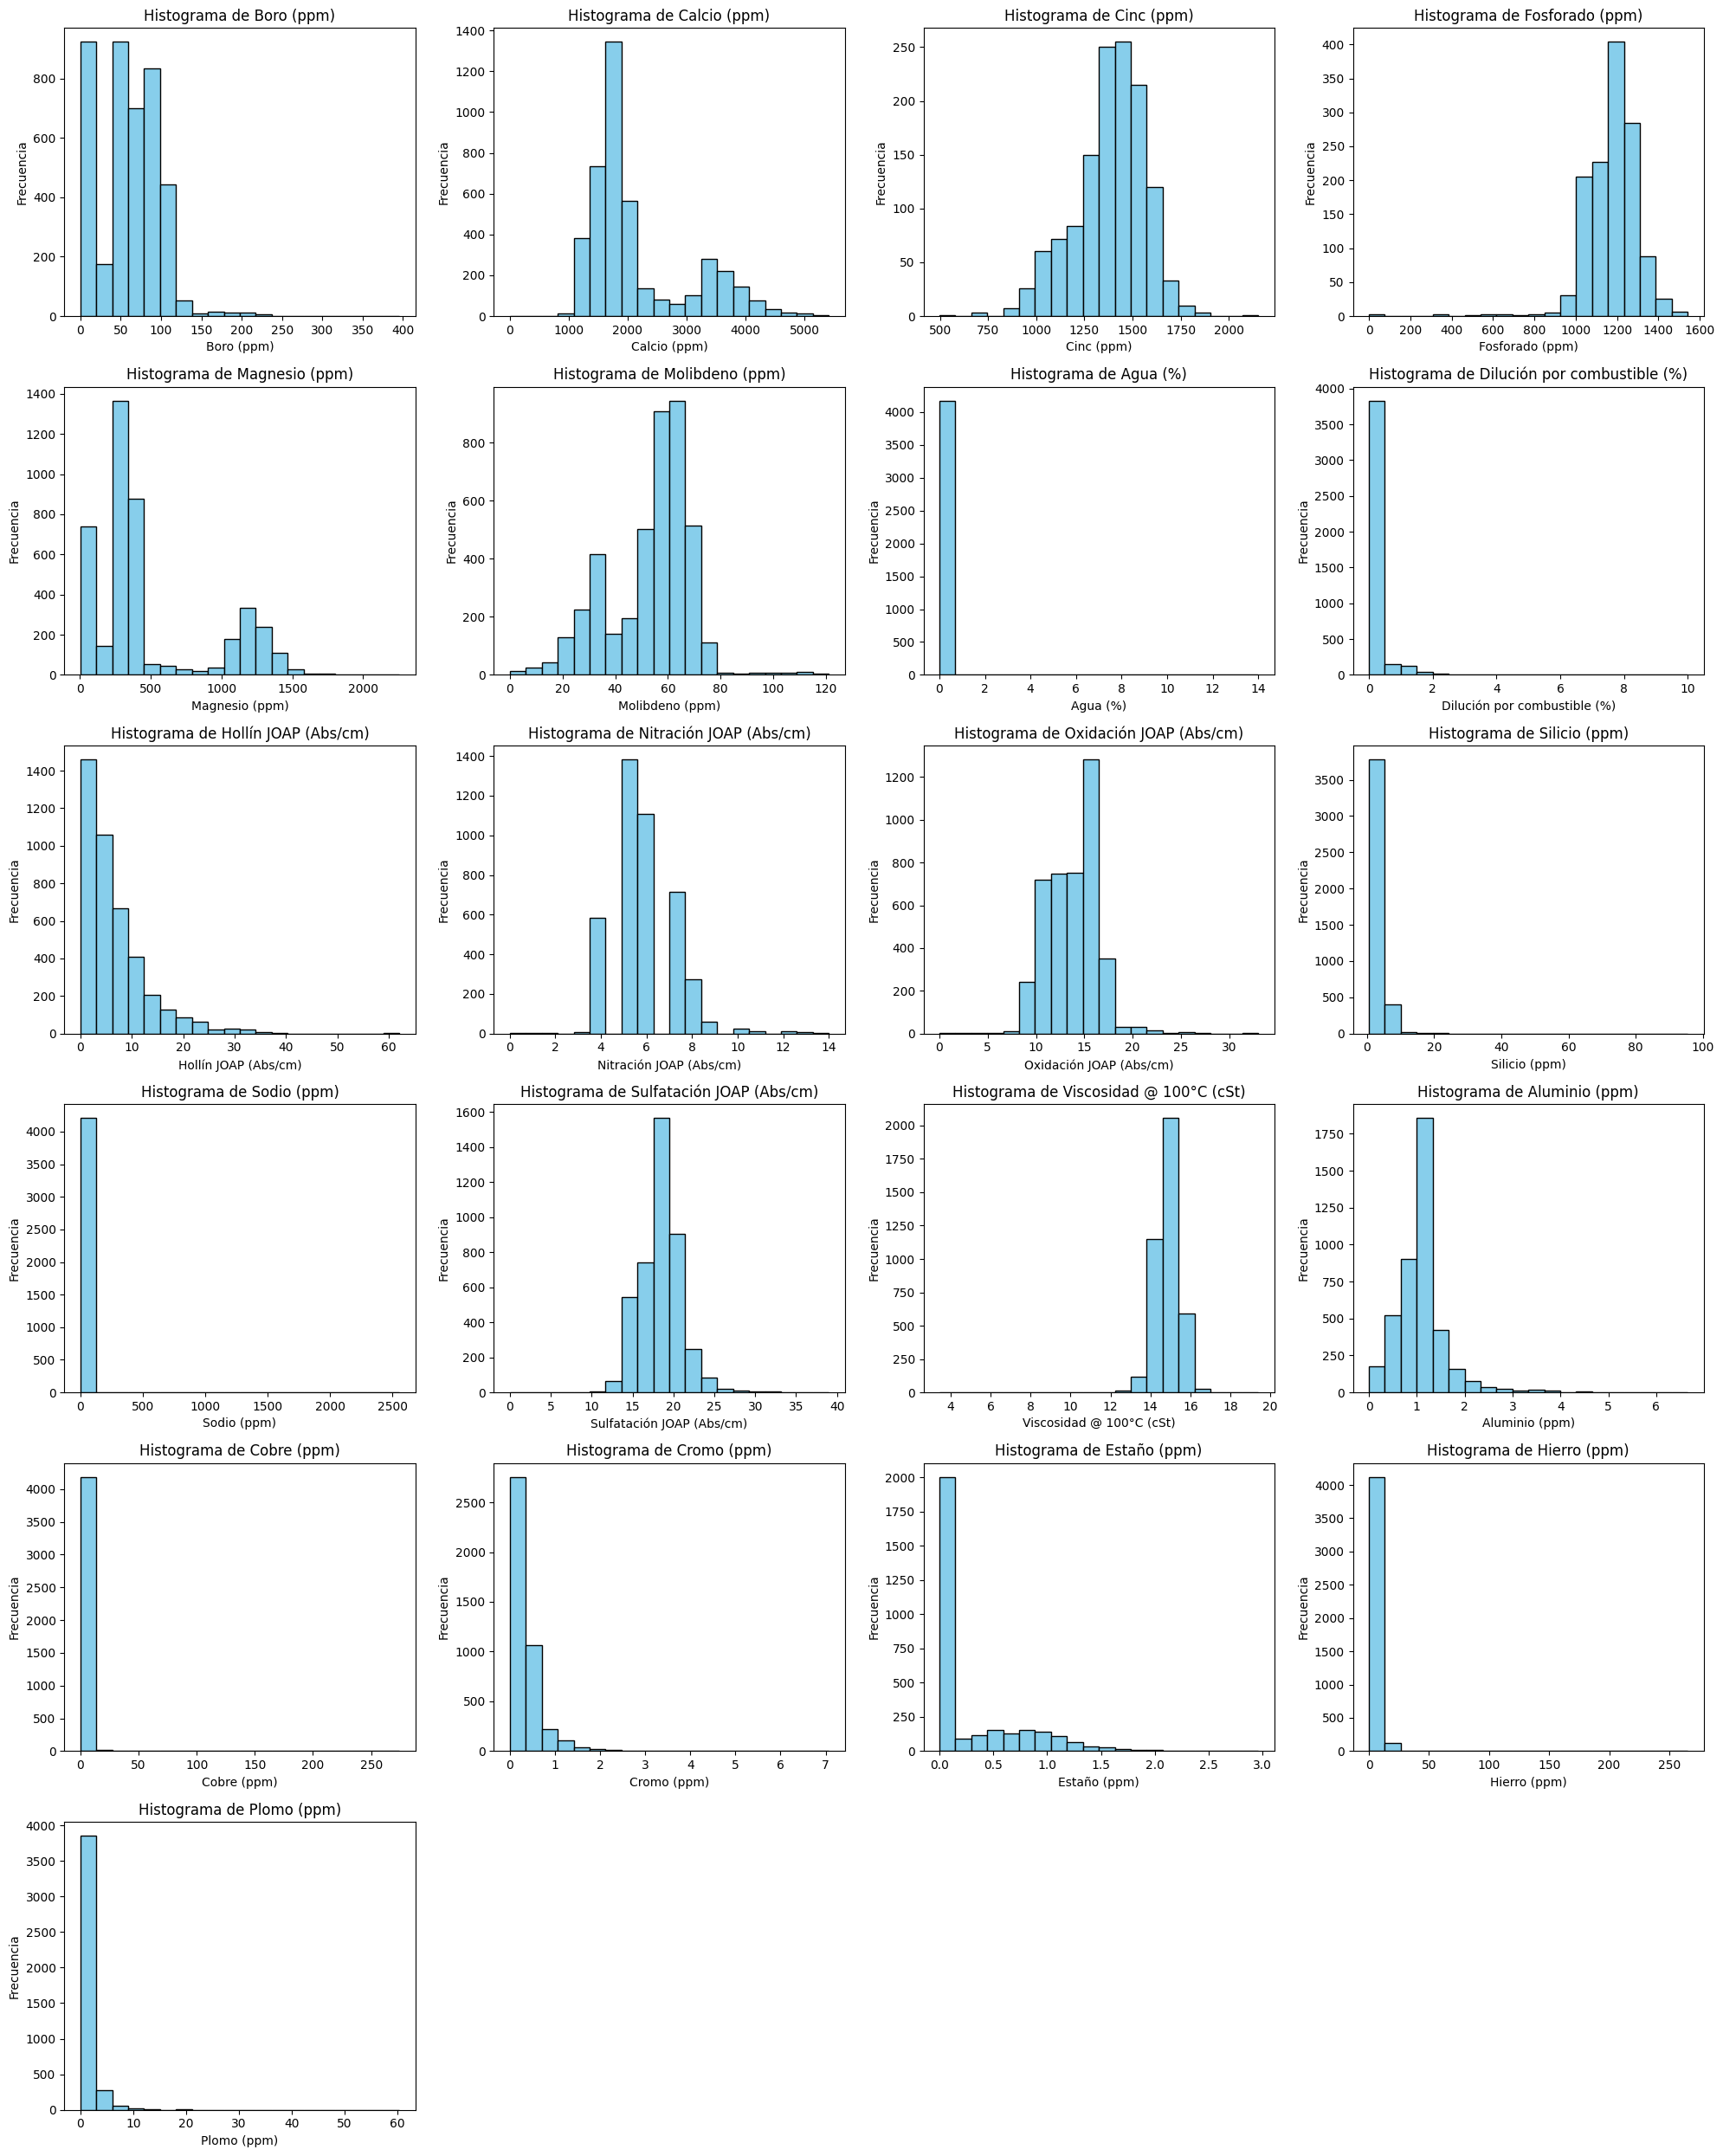

In [31]:
numerical_columns = data_cleaned.select_dtypes(include=['int64',"float64"]).columns

# Determinar el tamaño de la cuadrícula
n_cols = 4
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols  # Redondeo hacia arriba para que haya suficiente espacio

# Crear la figura y los ejes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 25))
axes = axes.flatten()  # Aplanar los ejes para iterar sobre ellos fácilmente

# Generar un histograma para cada columna numérica
for i, col in enumerate(numerical_columns):
    axes[i].hist(data_cleaned[col].dropna(), bins=20, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Histograma de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

# Eliminar cualquier gráfico extra (en caso de que haya más subplots que columnas)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Ajustar el espaciado entre gráficos
plt.tight_layout()
plt.show()

* La mayoría de las variables están fuertemente sesgadas a la derecha.
  * La mayoría de las variables muestran distribuciones fuertemente sesgadas a la derecha.
  * Hay colas largas y presencia evidente de outliers extremos en múltiples variables (metales, JOAP, sólidos disueltos, sodio, silicio, etc.).
  * Esto sugiere procesos con valores excepcionales pero poco frecuentes, típicos de análisis de aceite contaminado o en falla.
* Outliers extremos: hay valores aislados muy altos en varios contaminantes y lecturas temporales; se debe verificar si representan fallas reales o errores de medición.
* Variables con valores casi nulos o detección limitada: varios metales (Bario, Cadmio, Níquel, Vanadio, Titanio, etc.) concentran la mayoría de observaciones en 0-cercano a 0 con pocos valores detectables → posible límite de detección del instrumento
* Histogramas planos o vacíos indican alta falta de datos o constantes: ISO 4406 y algunas trazas muestran prácticamente ninguna variación, esto debido a que se trata de datos faltantes en su mayoria.
* Las variables relacionadas con tiempo o uso del equipo tienen gran dispersión.

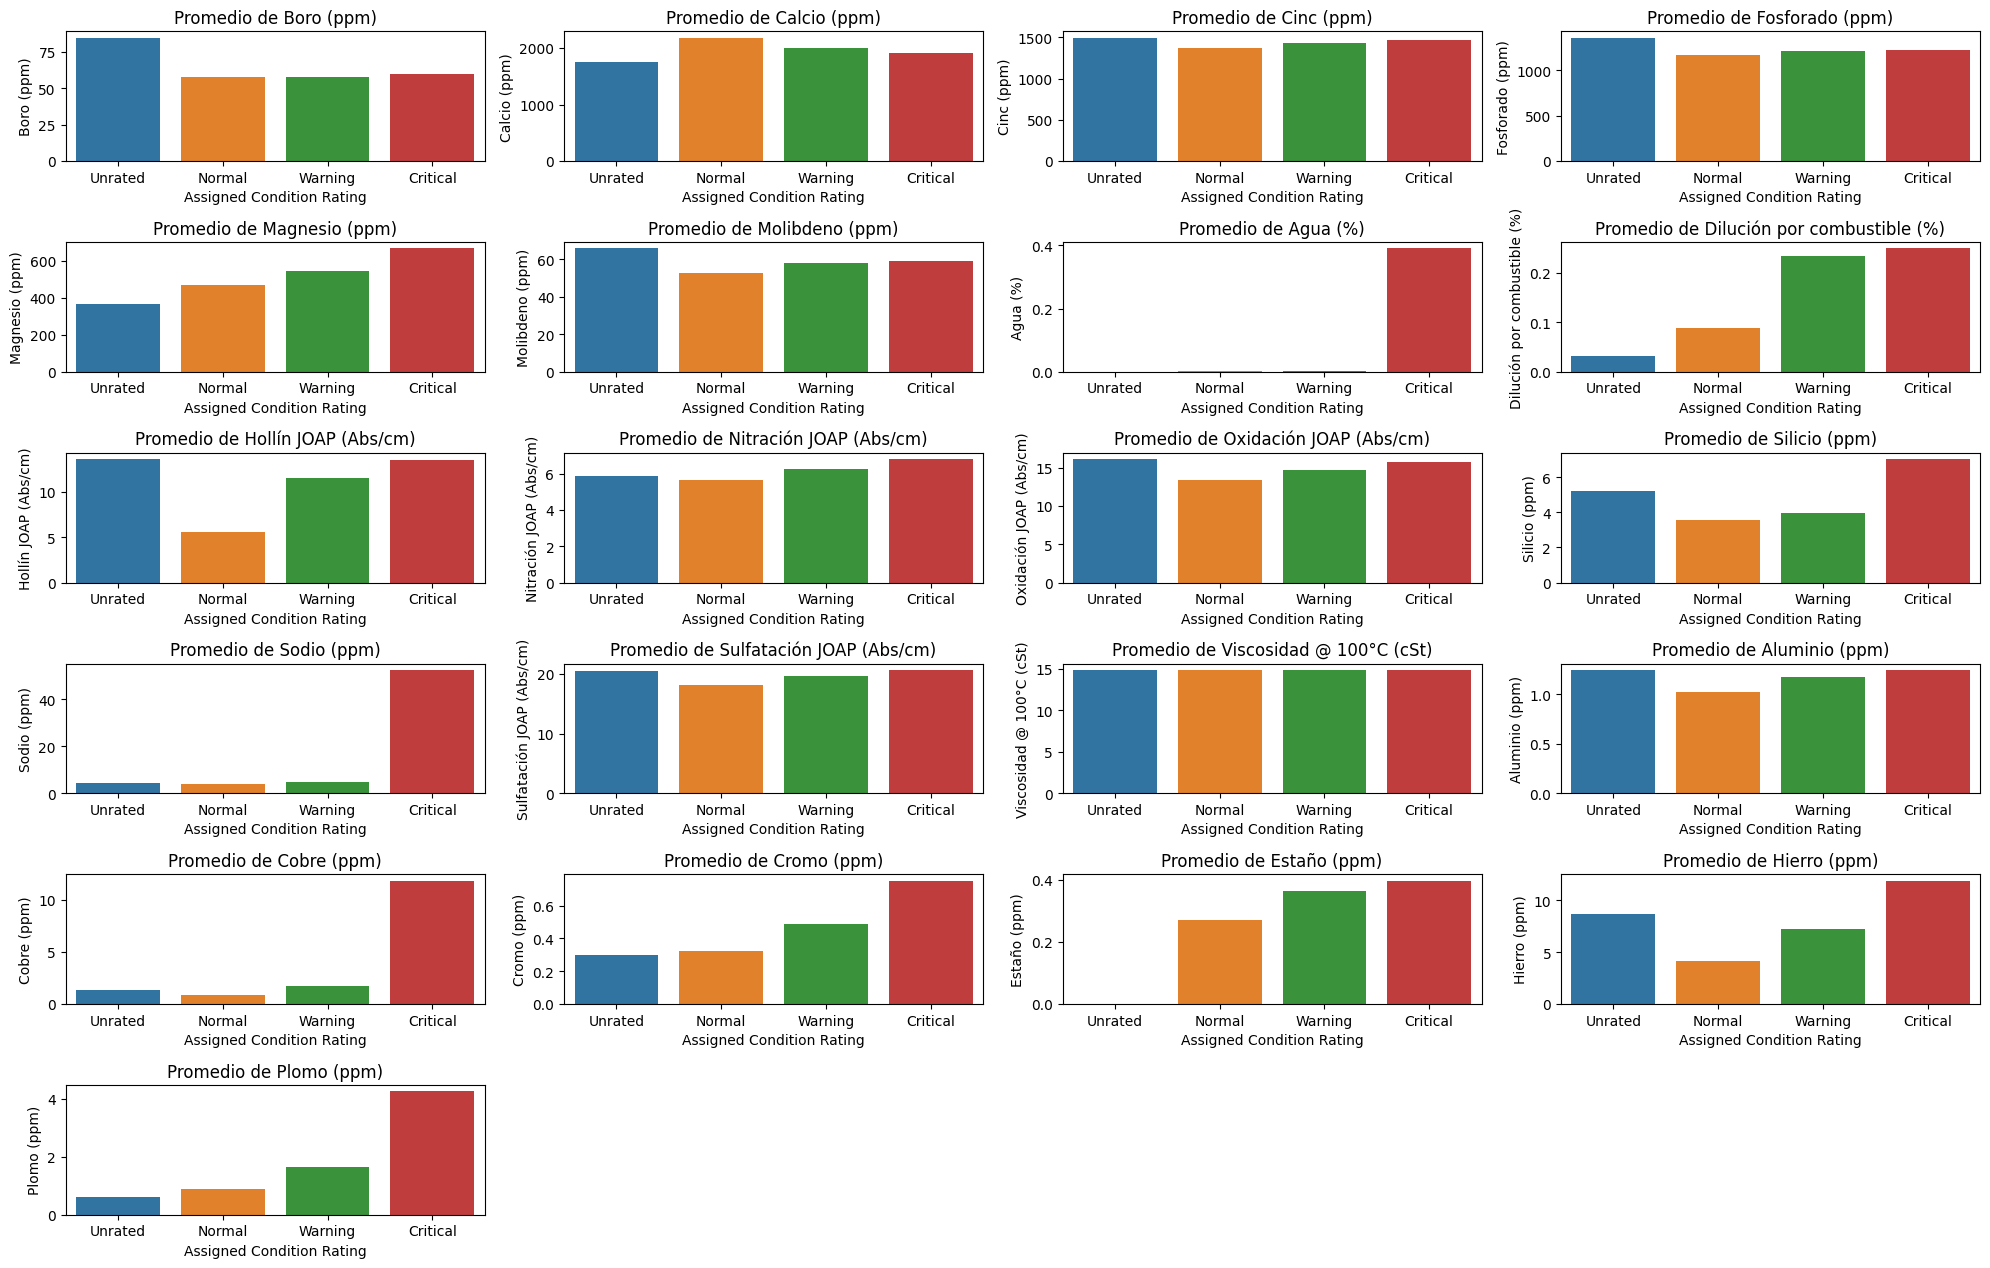

In [32]:
import seaborn as sns
plt.figure(figsize=(20, 25))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(12, 4, i)  
    sns.barplot(x='Assigned Condition Rating', y=col, data=data_cleaned, errorbar=None, hue='Assigned Condition Rating')
    plt.title(f'Promedio de {col}')
    plt.xlabel('Assigned Condition Rating')
    plt.ylabel(col)
    plt.xticks(rotation=0)

plt.tight_layout()  
plt.show()